# 🏢 Insurance Retention Dataset – Classification Task

## 🎯 Case
Prediction of customer policy renewal (retention).

The objective of this project is to predict whether a customer will renew their insurance policy based on demographic, product ownership, behavioral, and financial variables.

---

# 📊 Variables Description

#### PoliçeNumarası: Unique identifier of each insurance policy.  
(Not used in modeling, only for identification purposes.)

#### MüşteriCinsiyeti
Gender of the policyholder (Female / Male).  
May affect risk perception and product preference.

#### _65YaşÜzeri
Indicates whether the customer is over 65 years old (1 = Yes, 0 = No).  
Age is an important risk and loyalty factor in insurance analytics.

#### MedeniDurum
Marital status of the customer (Married / Single).  
Married customers may show different retention behavior due to family responsibilities.

#### ÇocukVarmı
Indicates whether the customer has children (Yes / No).  
Customers with dependents may have higher insurance commitment.

#### PoliçeSüresi
Number of months the customer has been insured.  
Longer duration generally indicates higher customer loyalty.

#### EvSigortasıVarlığı
Indicates whether the customer owns a home insurance policy.  
Used to analyze cross-selling and multi-product ownership.

#### AraçSigortasıVarlığı
Indicates vehicle insurance ownership status (Company / Competitor / None).  
Useful for competitive positioning analysis.

#### SağlıkSigortasıVarlığı
Type of health insurance coverage (Standard / Comprehensive / None).  
Coverage level may influence retention probability.

#### TicariSigortaVarlığı
Indicates whether the customer owns commercial insurance.  
Business customers may have different retention patterns.

#### ÇağrıMerkeziİletişimi
Frequency of customer interaction with the call center (None / Yes / Multiple).  
High interaction frequency may indicate dissatisfaction or engagement.

#### SonTedaviDetayı
Type of most recent medical treatment (Inpatient / Outpatient).  
Used as a risk and cost indicator.

#### AmeliyatGeçmişi
Indicates whether the customer has a surgical history (Yes / No).  
Important risk-related variable.

#### AileHayatSigortasıVarlığı
Indicates life insurance coverage type (None / Individual / Family).  
Multi-product ownership can increase retention.

#### SözleşmeTürü
Type of insurance contract (Basic / Premium).  
Premium contracts may have different renewal behavior.

#### BildirimTercihleri
Customer’s preferred communication channel (Email / SMS / Letter).  
Digital preference may correlate with engagement level.

#### ÖdemeYöntemi
Payment method (Credit Card Installment / Automatic Payment / Bank Transfer).  
Automatic payments are often associated with higher retention.

#### AylıkÖdemeTutarı
Monthly premium paid by the customer.  
Important financial factor in churn prediction.

#### ToplamÖdemeTutarı
Total premium paid over the policy duration.  
Reflects customer value and lifetime contribution.

#### 🎯 PoliçeYenilemeDurumu (Target Variable)
Indicates whether the customer renewed the policy.

- 1 (Evet) → Retained  
- 0 (Negatif) → Churned  

This is the target variable for the classification model.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.model_selection import train_test_split,RandomizedSearchCV,cross_val_score,GridSearchCV,cross_validate
import sklearn.metrics as metrics 
import matplotlib.cm as cm

# algorithms
import xgboost as xgb
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# data preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler,OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


import warnings
warnings.filterwarnings("ignore")

# metrics
from sklearn.metrics import mean_squared_error, r2_score ,explained_variance_score

In [2]:
# Load the data
df_= pd.read_csv("insuranceretention.csv", delimiter = ",")
df=df_.copy()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   PoliçeNumarası             15000 non-null  object
 1   MüşteriCinsiyeti           15000 non-null  object
 2   _65YaşÜzeri                15000 non-null  int64 
 3   MedeniDurum                15000 non-null  object
 4   ÇocukVarmı                 15000 non-null  object
 5   PoliçeSüresi               15000 non-null  int64 
 6   EvSigortasıVarlığı         15000 non-null  object
 7   AraçSigortasıVarlığı       15000 non-null  object
 8   SağlıkSigortasıVarlığı     15000 non-null  object
 9   TicariSigortaVarlığı       15000 non-null  object
 10  MobilUygulamaKullanımı     15000 non-null  object
 11  ÇağrıMerkeziİletişimi      15000 non-null  object
 12  SonTedaviDetayı            15000 non-null  object
 13  AmeliyatGeçmişi            15000 non-null  object
 14  AileHa

In [4]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


PoliçeNumarası
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '3503-LRPRB' '7448-GKOLK'
 '6748-BLTKY']

MüşteriCinsiyeti
['Kadın' 'Erkek']

_65YaşÜzeri
[0 1]

MedeniDurum
['Evet' 'Hayır']

ÇocukVarmı
['Hayır' 'Evet']

PoliçeSüresi
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

EvSigortasıVarlığı
['Yok' 'Var']

AraçSigortasıVarlığı
['Sigortasiz' 'Rakip' 'Var']

SağlıkSigortasıVarlığı
['VarStandard' 'VarKapsamli' 'Yok']

TicariSigortaVarlığı
['Rakipte' 'Var' 'TicariDegil']

MobilUygulamaKullanımı
['Kullaniyor' 'Kullanmiyor']

ÇağrıMerkeziİletişimi
['Evet' 'BirdenFazla' 'Hayir']

SonTedaviDetayı
['Ayakta' 'Yatis' '3 Aydir Yok']

AmeliyatGeçmişi
['Hayir' 'Evet' 'Planlanan']

AileHayatSigortasıVarlığı
['Yok' 'TekKisi' 'Var']

SözleşmeTürü
['Temel Hayat Sigortası' 'Özel Hayat Sigortası'
 'Prim Geri Ödemeli Hayat Sigort

In [5]:
df.describe([0.05, 0.1, 0.5, 0.75, 0.90, 0.95, 0.99]).T

,count,mean,std,min,5%,10%,50%,75%,90%,95%,99%,max
_65YaşÜzeri,15000.0,0.160467,0.367051,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
PoliçeSüresi,15000.0,32.010467,24.527026,0.0,1.0,2.0,28.0,55.0,69.0,71.0,72.0,72.0
AylıkÖdemeTutarı,15000.0,64.337933,30.193354,18.0,20.0,20.0,70.0,90.0,103.0,107.0,115.0,119.0
ToplamÖdemeTutarı,15000.0,2289.964000,2276.888337,19.0,50.0,85.0,1400.5,3808.0,5987.0,6990.1,8059.0,8685.0


In [6]:
df.describe(include='O').T 

,count,unique,top,freq
PoliçeNumarası,15000,15000,7590-VHVEG,1
MüşteriCinsiyeti,15000,2,Erkek,7594
MedeniDurum,15000,2,Hayır,7709
ÇocukVarmı,15000,2,Hayır,10486
EvSigortasıVarlığı,15000,2,Var,13549
AraçSigortasıVarlığı,15000,3,Rakip,7268
SağlıkSigortasıVarlığı,15000,3,VarKapsamli,6600
TicariSigortaVarlığı,15000,3,Rakipte,7394
MobilUygulamaKullanımı,15000,2,Kullanmiyor,9815
ÇağrıMerkeziİletişimi,15000,3,Evet,6655


In [7]:
#df.describe(include='all').T

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

PoliçeNumarası               0
MüşteriCinsiyeti             0
_65YaşÜzeri                  0
MedeniDurum                  0
ÇocukVarmı                   0
PoliçeSüresi                 0
EvSigortasıVarlığı           0
AraçSigortasıVarlığı         0
SağlıkSigortasıVarlığı       0
TicariSigortaVarlığı         0
MobilUygulamaKullanımı       0
ÇağrıMerkeziİletişimi        0
SonTedaviDetayı              0
AmeliyatGeçmişi              0
AileHayatSigortasıVarlığı    0
SözleşmeTürü                 0
BildirimTercihleri           0
ÖdemeYöntemi                 0
AylıkÖdemeTutarı             0
ToplamÖdemeTutarı            0
PoliçeYenilemeDurumu         0
dtype: int64

In [10]:
df.drop("PoliçeNumarası", axis=1, inplace=True)

In [11]:
df["_65YaşÜzeri"] = df["_65YaşÜzeri"].astype("object")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   MüşteriCinsiyeti           15000 non-null  object
 1   _65YaşÜzeri                15000 non-null  object
 2   MedeniDurum                15000 non-null  object
 3   ÇocukVarmı                 15000 non-null  object
 4   PoliçeSüresi               15000 non-null  int64 
 5   EvSigortasıVarlığı         15000 non-null  object
 6   AraçSigortasıVarlığı       15000 non-null  object
 7   SağlıkSigortasıVarlığı     15000 non-null  object
 8   TicariSigortaVarlığı       15000 non-null  object
 9   MobilUygulamaKullanımı     15000 non-null  object
 10  ÇağrıMerkeziİletişimi      15000 non-null  object
 11  SonTedaviDetayı            15000 non-null  object
 12  AmeliyatGeçmişi            15000 non-null  object
 13  AileHayatSigortasıVarlığı  15000 non-null  object
 14  Sözleş

In [13]:
df["YenilemeBinary"] = 0
df.loc[df["PoliçeYenilemeDurumu"] == "Evet", "YenilemeBinary"] = 1

In [14]:
#numerics = ["PoliçeSüresi", "AylıkÖdemeTutarı", "ToplamÖdemeTutarı"]

In [15]:
#demographics = ["MüşteriCinsiyeti", 'MedeniDurum', 'ÇocukVarmı', 'MedeniDurum']
#products = ['EvSigortasıVarlığı', 'AraçSigortasıVarlığı', 'SağlıkSigortasıVarlığı','TicariSigortaVarlığı','AileHayatSigortasıVarlığı']
#davranis = ['ÇağrıMerkeziİletişimi', 'SonTedaviDetayı', 'AmeliyatGeçmişi','ÖdemeYöntemi','BildirimTercihleri']

In [16]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols=df.select_dtypes(exclude=['object', 'category']).columns.tolist()

In [17]:
print('cat_cols: ', cat_cols)
print("*****************************")
print('num_cols: ', num_cols)

cat_cols:  ['MüşteriCinsiyeti', '_65YaşÜzeri', 'MedeniDurum', 'ÇocukVarmı', 'EvSigortasıVarlığı', 'AraçSigortasıVarlığı', 'SağlıkSigortasıVarlığı', 'TicariSigortaVarlığı', 'MobilUygulamaKullanımı', 'ÇağrıMerkeziİletişimi', 'SonTedaviDetayı', 'AmeliyatGeçmişi', 'AileHayatSigortasıVarlığı', 'SözleşmeTürü', 'BildirimTercihleri', 'ÖdemeYöntemi', 'PoliçeYenilemeDurumu']
*****************************
num_cols:  ['PoliçeSüresi', 'AylıkÖdemeTutarı', 'ToplamÖdemeTutarı', 'YenilemeBinary']


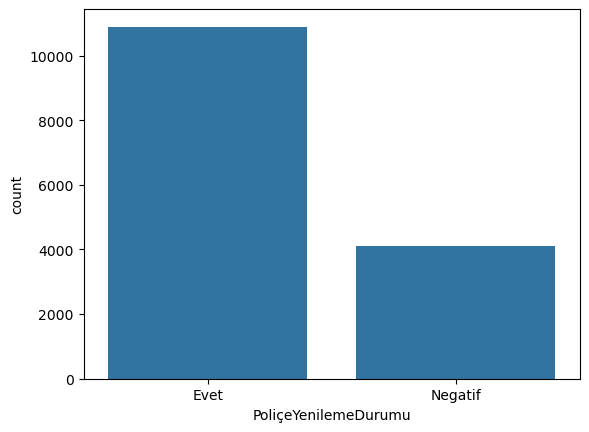

In [18]:
df["PoliçeYenilemeDurumu"].value_counts(normalize=True)
sns.countplot(x="PoliçeYenilemeDurumu", data=df)
plt.show()


In [19]:
df.groupby("PoliçeYenilemeDurumu")[num_cols].mean()

,PoliçeSüresi,AylıkÖdemeTutarı,ToplamÖdemeTutarı,YenilemeBinary
PoliçeYenilemeDurumu,,,,
Evet,34.357595,62.733272,2416.510785,1.0
Negatif,25.780999,68.596833,1954.098660,0.0


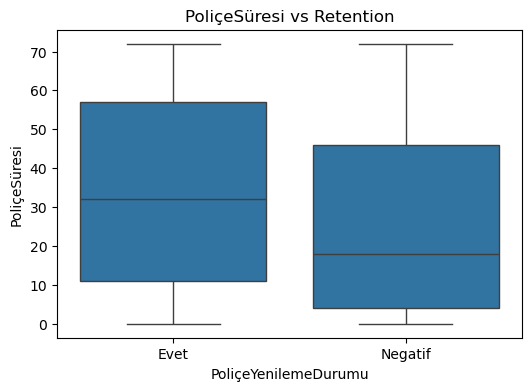

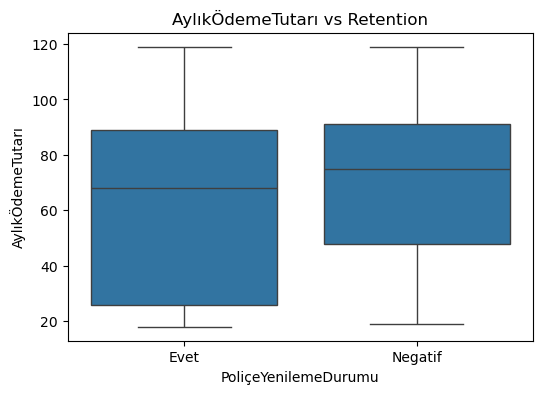

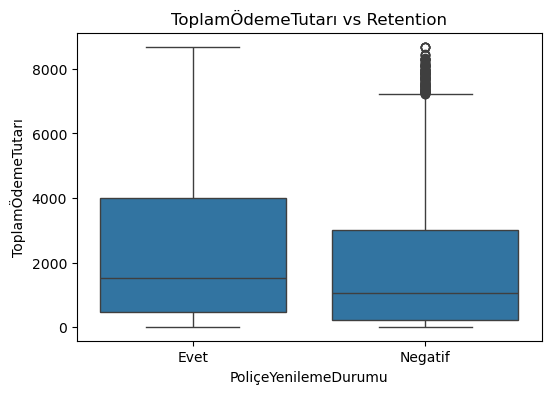

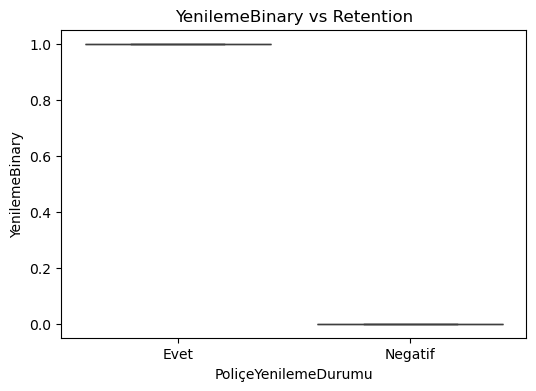

In [20]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="PoliçeYenilemeDurumu", y=col, data=df)
    plt.title(f"{col} vs Retention")
    plt.show()


In [21]:
#Ortalama ödeme ne kadar?
#Çok yüksek / çok düşük uç değer var mı?
#Poliçe süresi kısa olanlar çoğunlukta mı?

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PoliçeSüresi,15000.0,32.010467,24.527026,0.0,8.0,28.0,55.0,72.0
AylıkÖdemeTutarı,15000.0,64.337933,30.193354,18.0,35.0,70.0,90.0,119.0
ToplamÖdemeTutarı,15000.0,2289.964000,2276.888337,19.0,410.0,1400.5,3808.0,8685.0
YenilemeBinary,15000.0,0.726333,0.445855,0.0,0.0,1.0,1.0,1.0


In [22]:
cats = ["MüşteriCinsiyeti", "_65YaşÜzeri", "MedeniDurum", "ÇocukVarmı", "ÇağrıMerkeziİletişimi", "SözleşmeTürü", "ÖdemeYöntemi"]

In [23]:
for col in cats:
    print("*********")
    print(df[col].value_counts())

*********
MüşteriCinsiyeti
Erkek    7594
Kadın    7406
Name: count, dtype: int64
*********
_65YaşÜzeri
0    12593
1     2407
Name: count, dtype: int64
*********
MedeniDurum
Hayır    7709
Evet     7291
Name: count, dtype: int64
*********
ÇocukVarmı
Hayır    10486
Evet      4514
Name: count, dtype: int64
*********
ÇağrıMerkeziİletişimi
Evet           6655
BirdenFazla    5056
Hayir          3289
Name: count, dtype: int64
*********
SözleşmeTürü
Temel Hayat Sigortası                8247
Prim Geri Ödemeli Hayat Sigortası    3635
Özel Hayat Sigortası                 3118
Name: count, dtype: int64
*********
ÖdemeYöntemi
Kredi Kartı ile Taksitli Ödeme    9991
Otomatik Ödeme Talimatı           5009
Name: count, dtype: int64


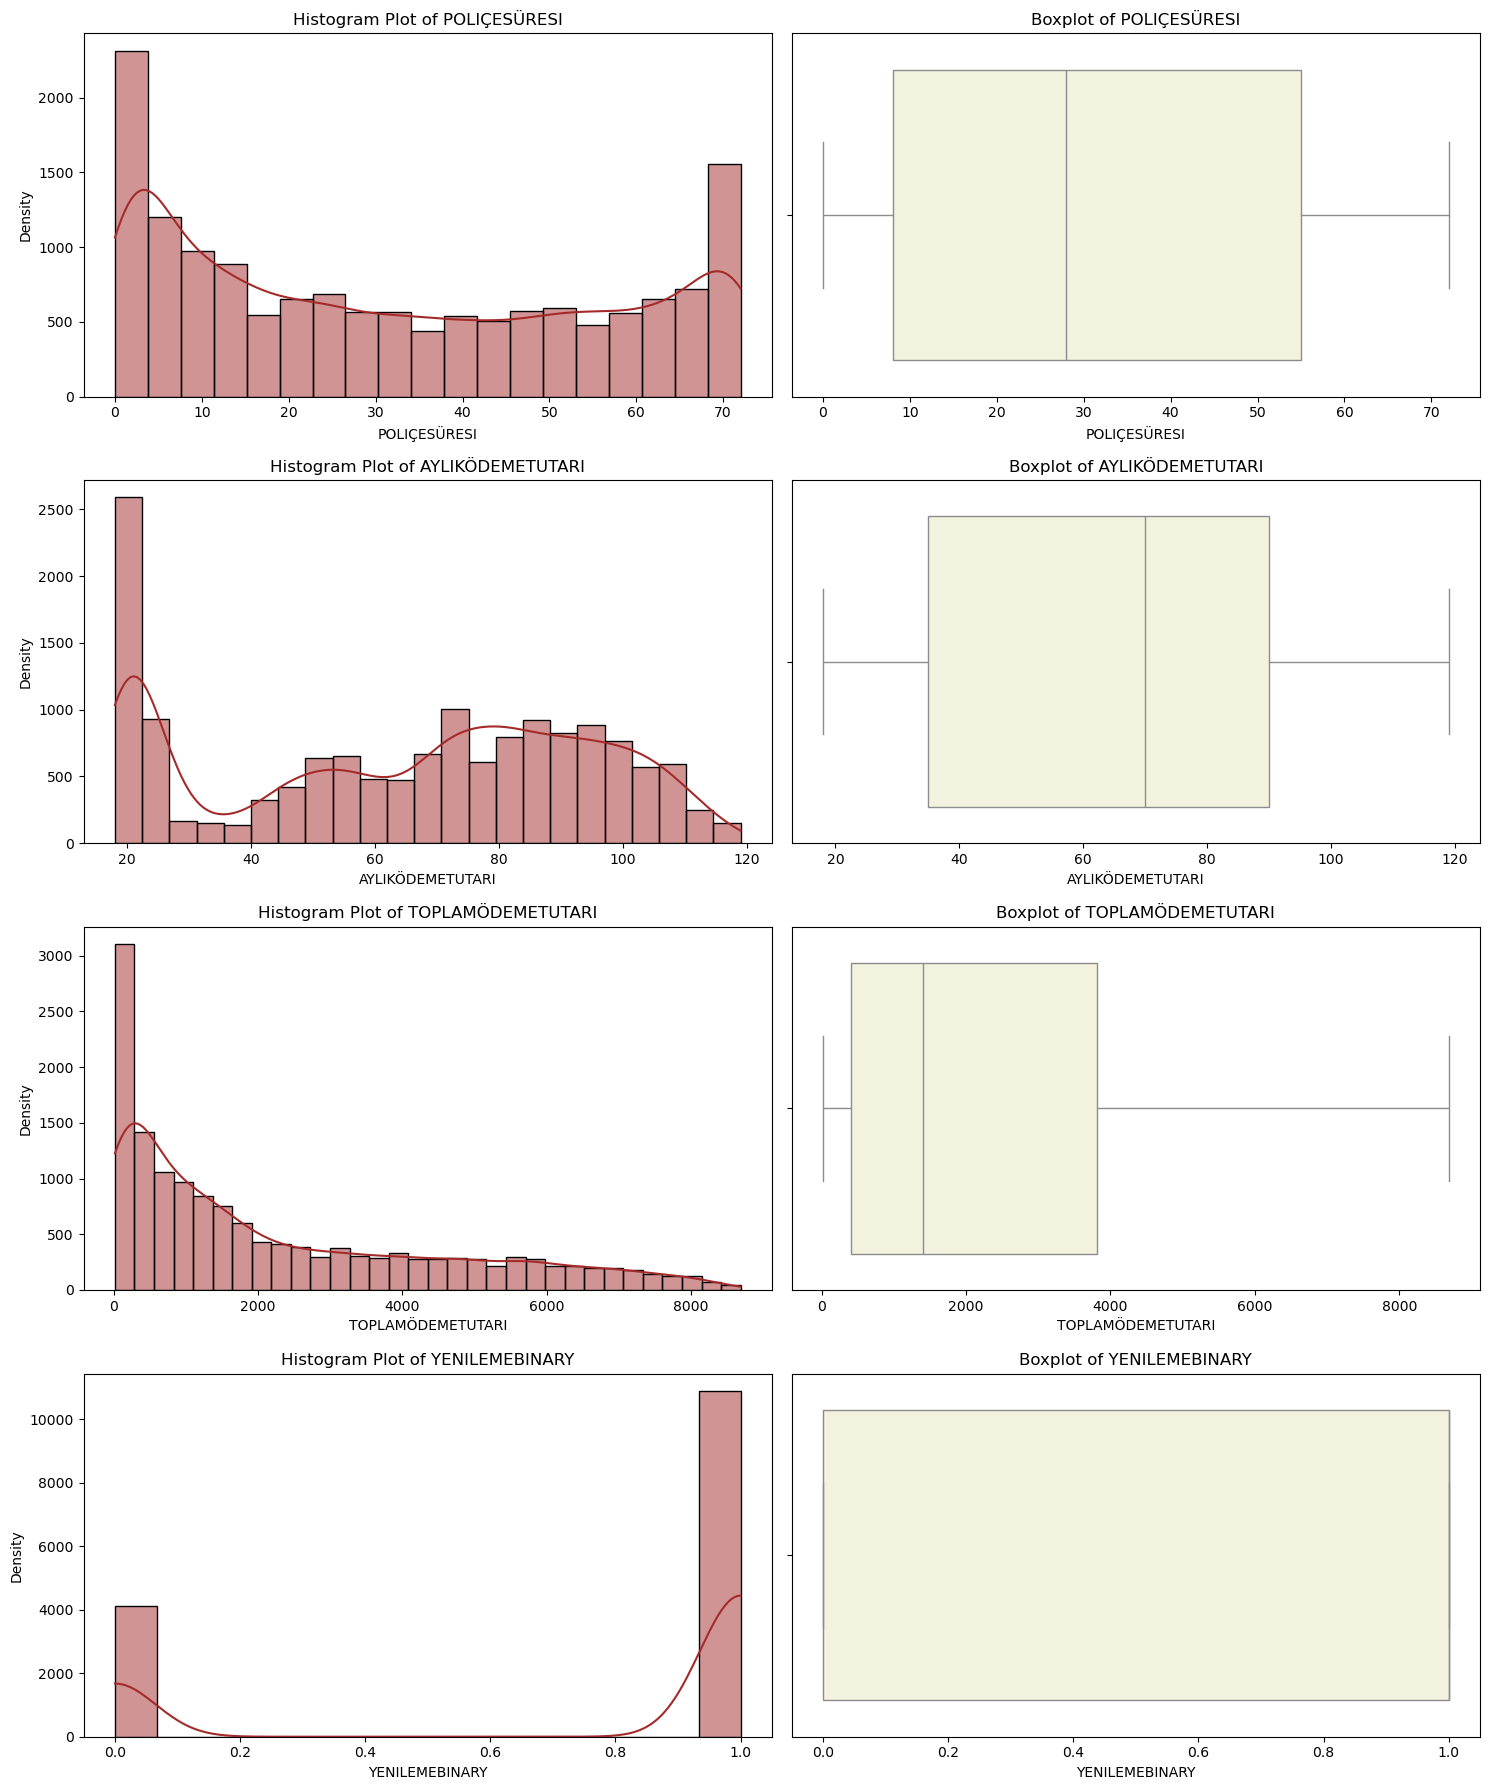

In [24]:
plt.figure(figsize=(15, 18))
for i, col in enumerate(num_cols):
    # Distribution
    plt.subplot(4, 2, 2*i+1)   
    sns.histplot(df[col], kde=True, color='brown')
    plt.xlabel(f"{col.upper()}")
    plt.ylabel('Density')
    plt.title(f"Histogram Plot of {col.upper()}")
    plt.tight_layout()
    
    # Boxplot
    plt.subplot(4, 2, 2*i+2)   
    sns.boxplot(df[col], orient='h', color='beige')
    plt.xlabel(f"{col.upper()}")
    plt.title(f"Boxplot of {col.upper()}")
plt.show()

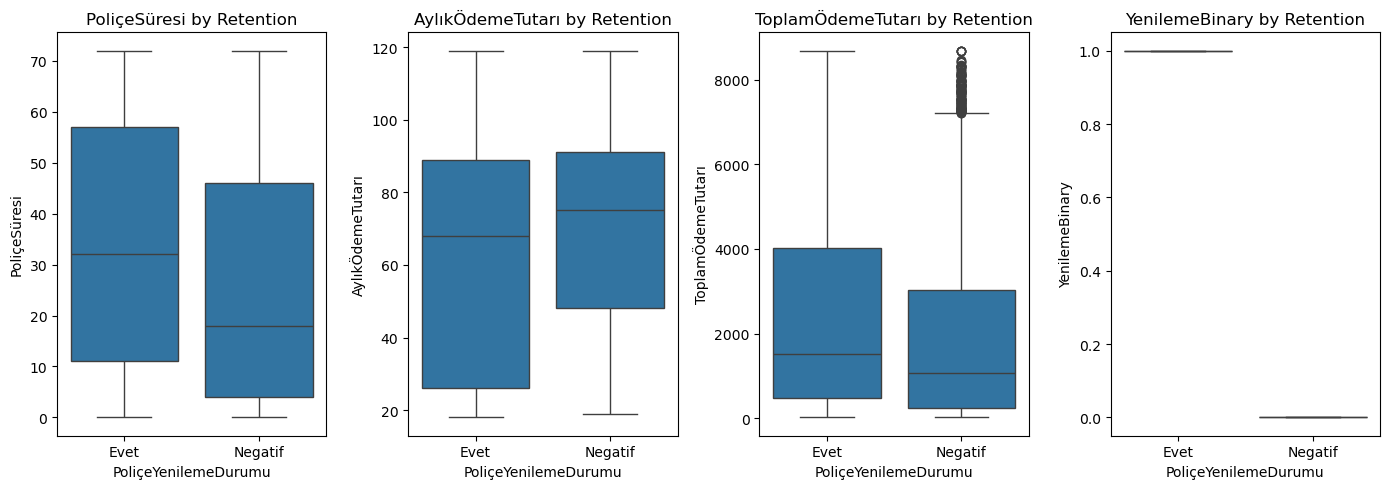

In [25]:
plt.figure(figsize=(14, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(data=df, x="PoliçeYenilemeDurumu", y=col)
    plt.title(f"{col} by Retention")
plt.tight_layout()
plt.show()

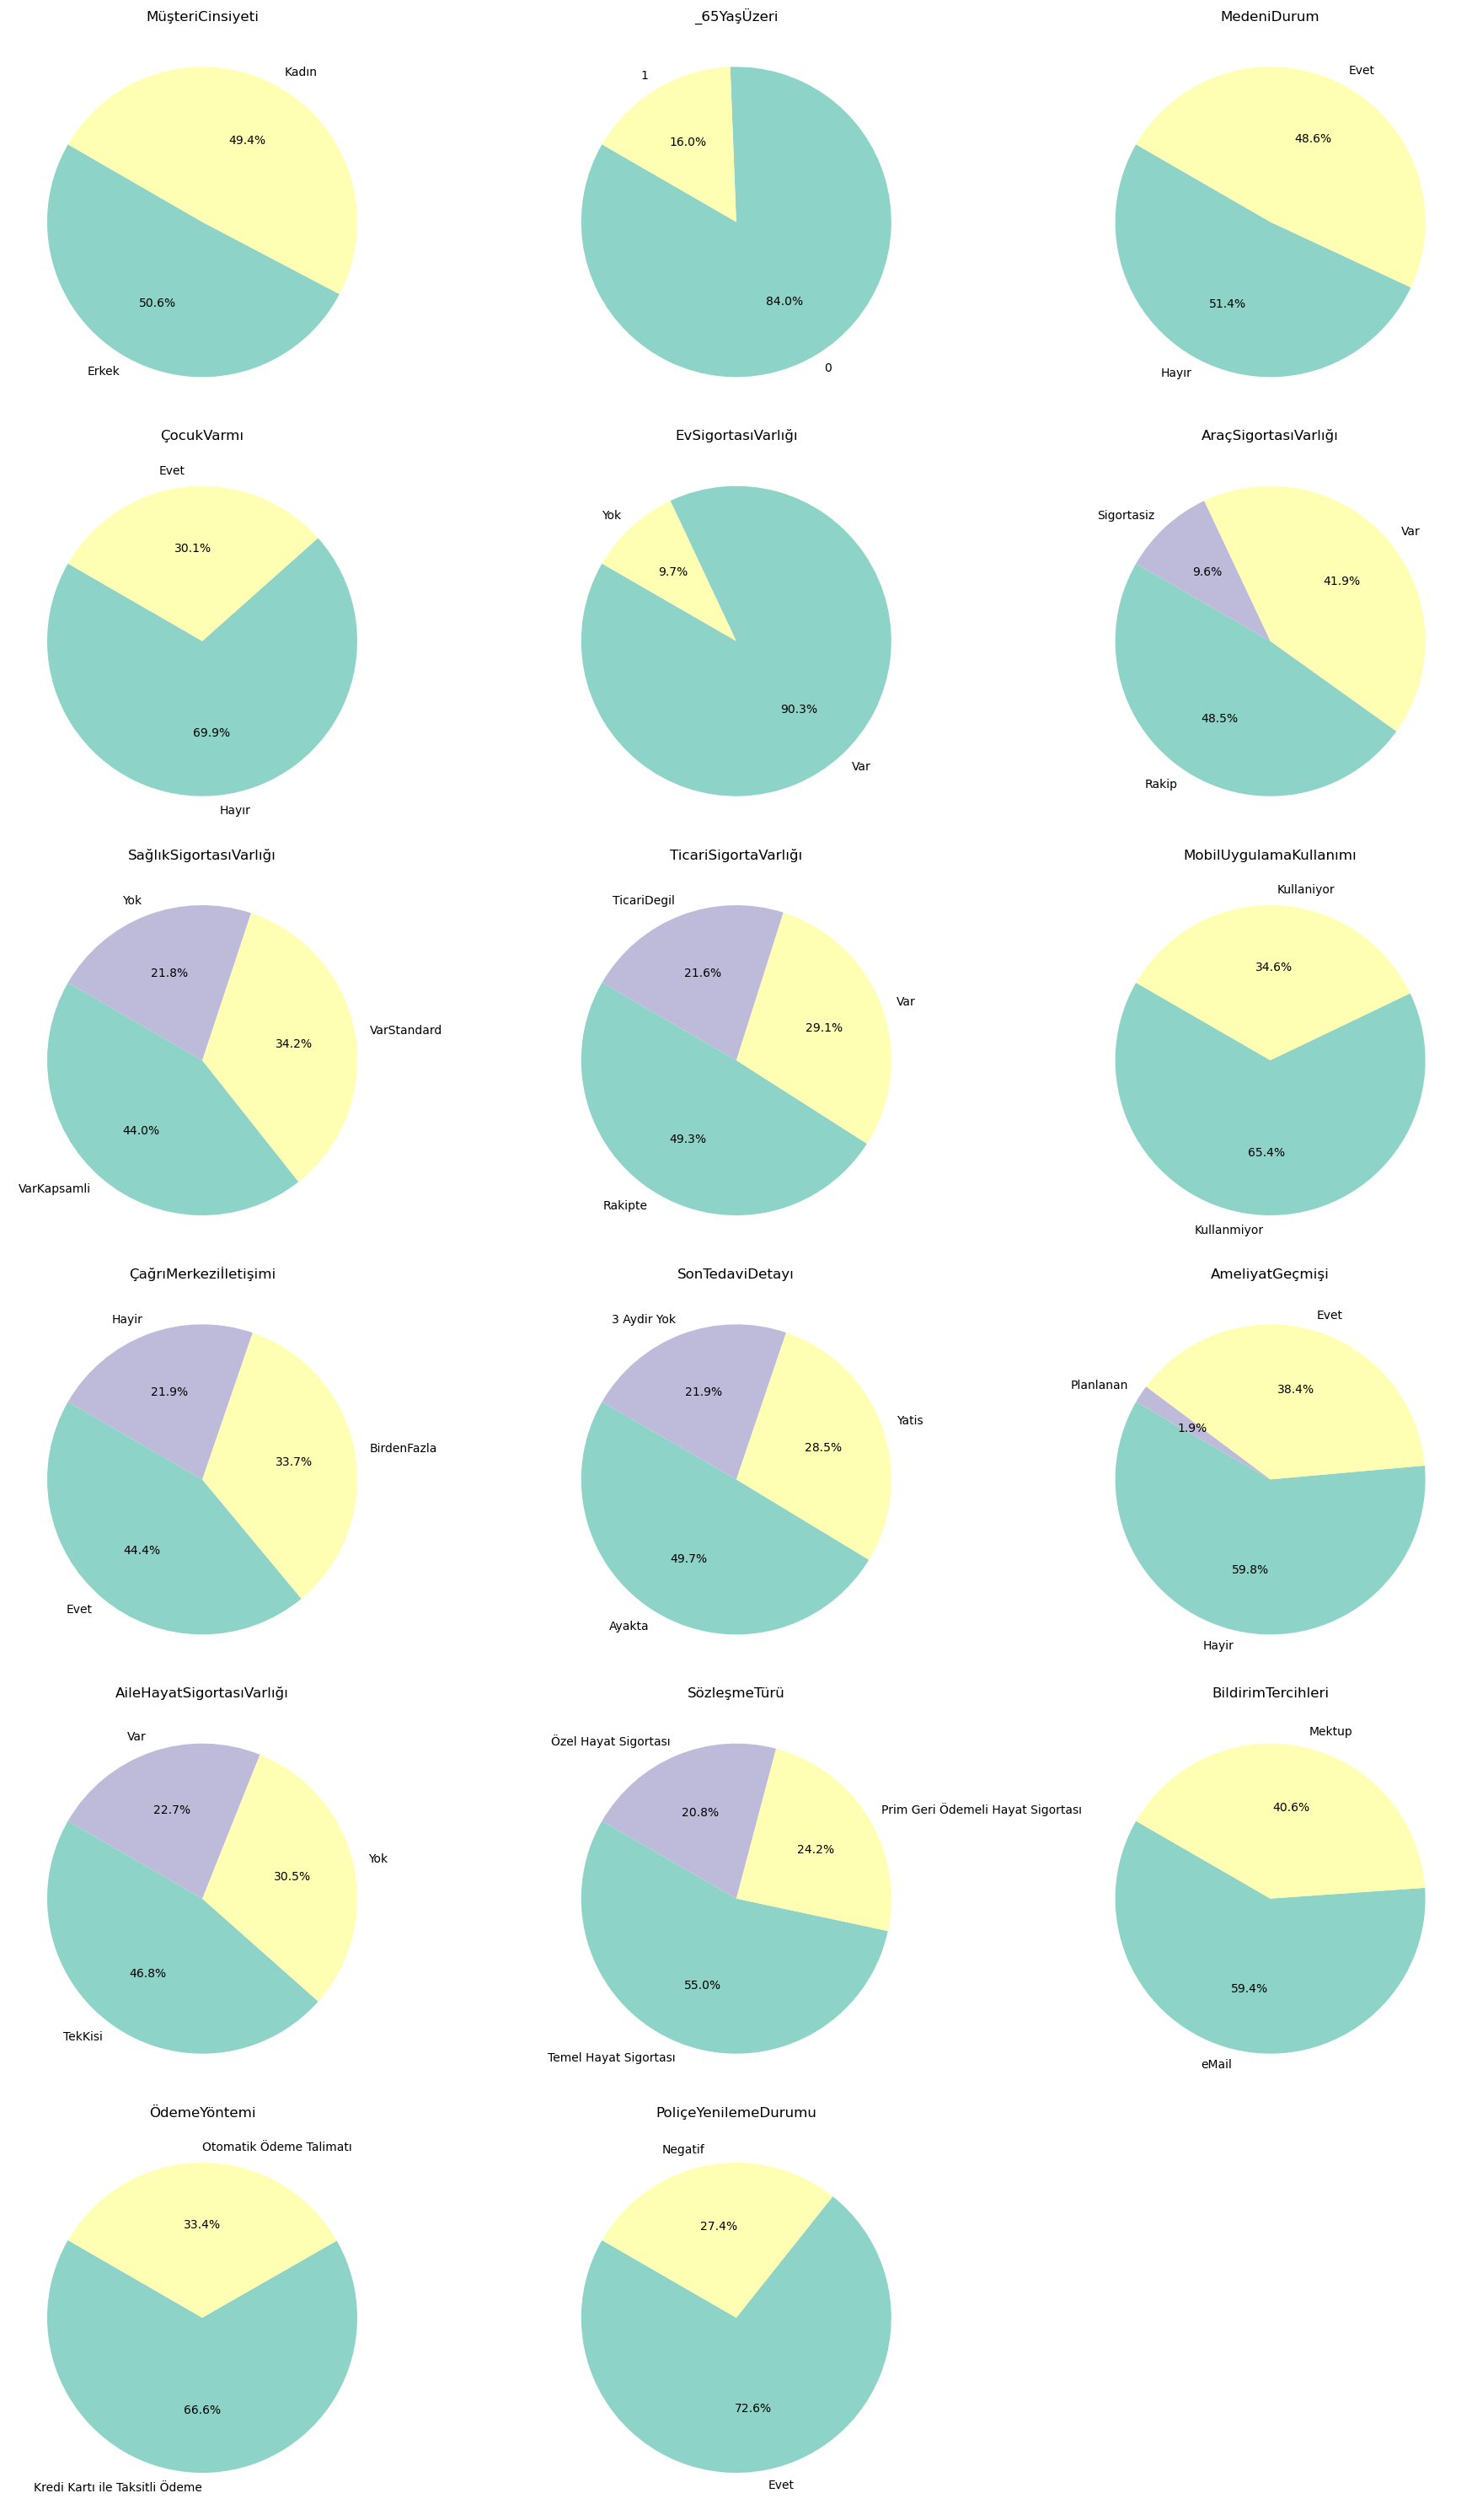

In [26]:
#gpt önerisi
n_cols = 3  # her satırda 3 grafik
n_rows = math.ceil(len(cat_cols) / n_cols)

colors = cm.Set3.colors

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i+1)
    
    value_counts = df[col].value_counts()
    
    plt.pie(
        value_counts,
        labels=value_counts.index,
        autopct='%1.1f%%',
        startangle=150,
        colors=colors[:len(value_counts)]
    )
    
    plt.title(f"{col}")
    
plt.tight_layout()
plt.show()

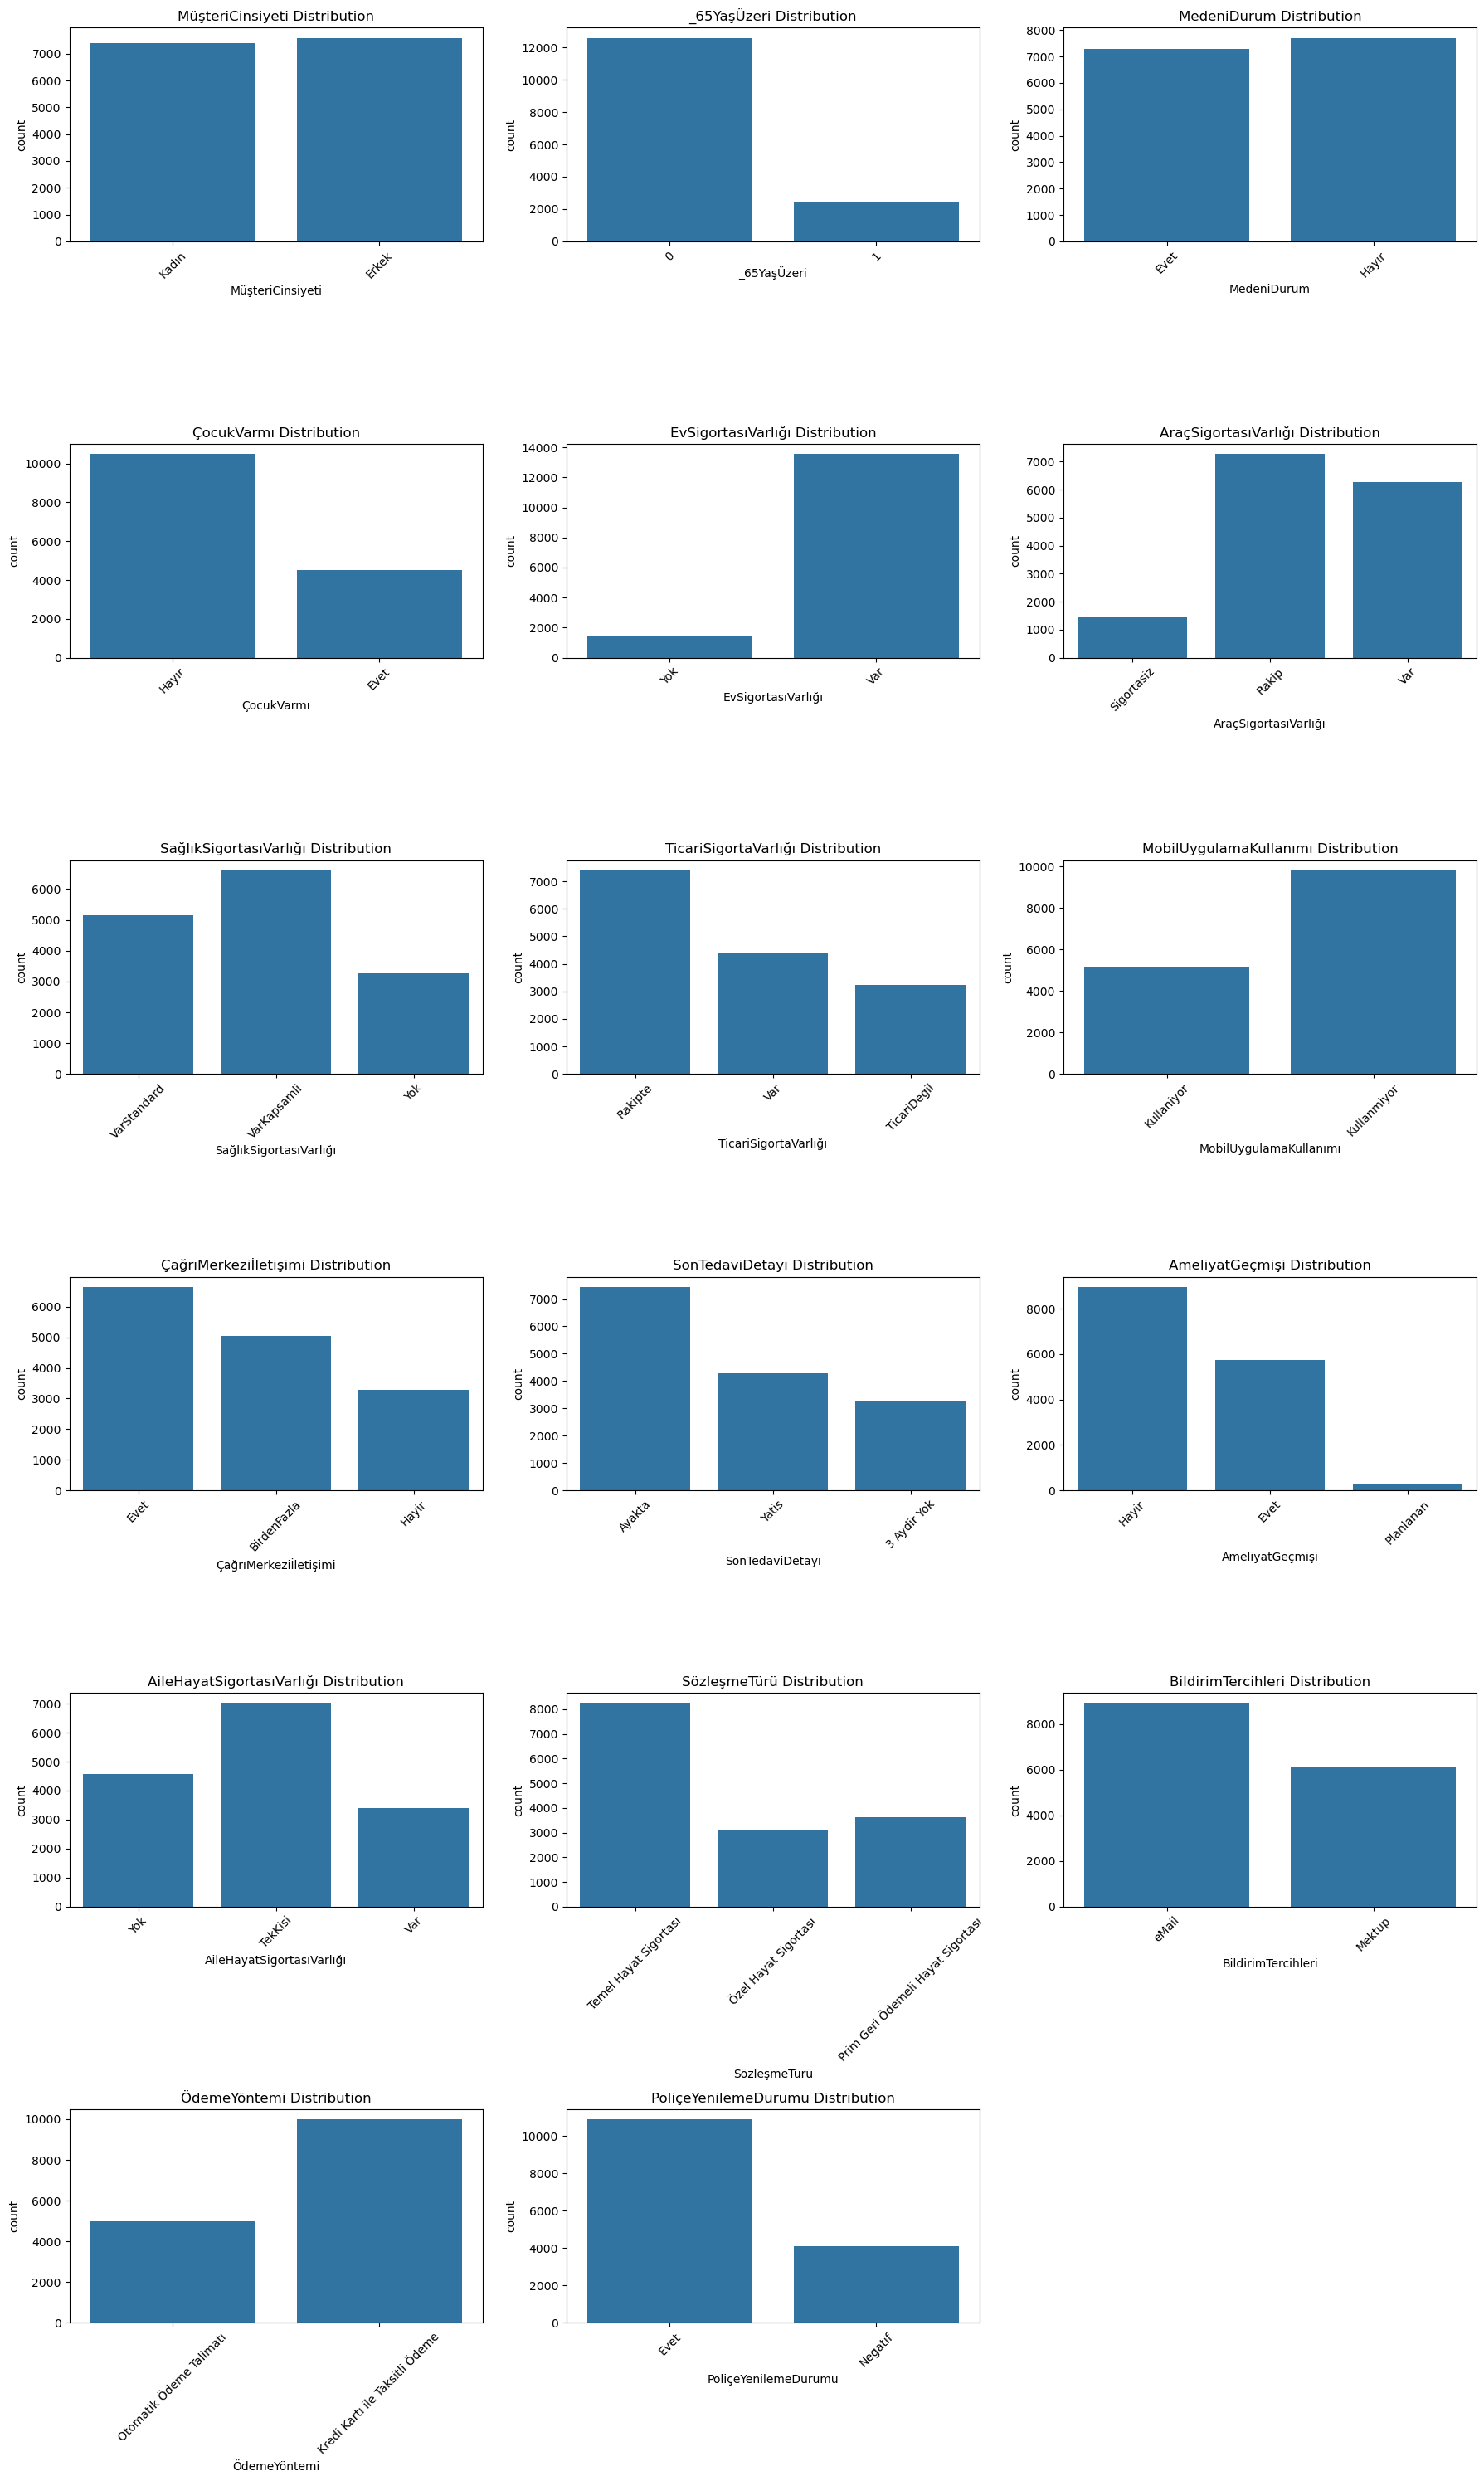

In [27]:
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i+1)
    
    sns.countplot(data=df, x=col)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

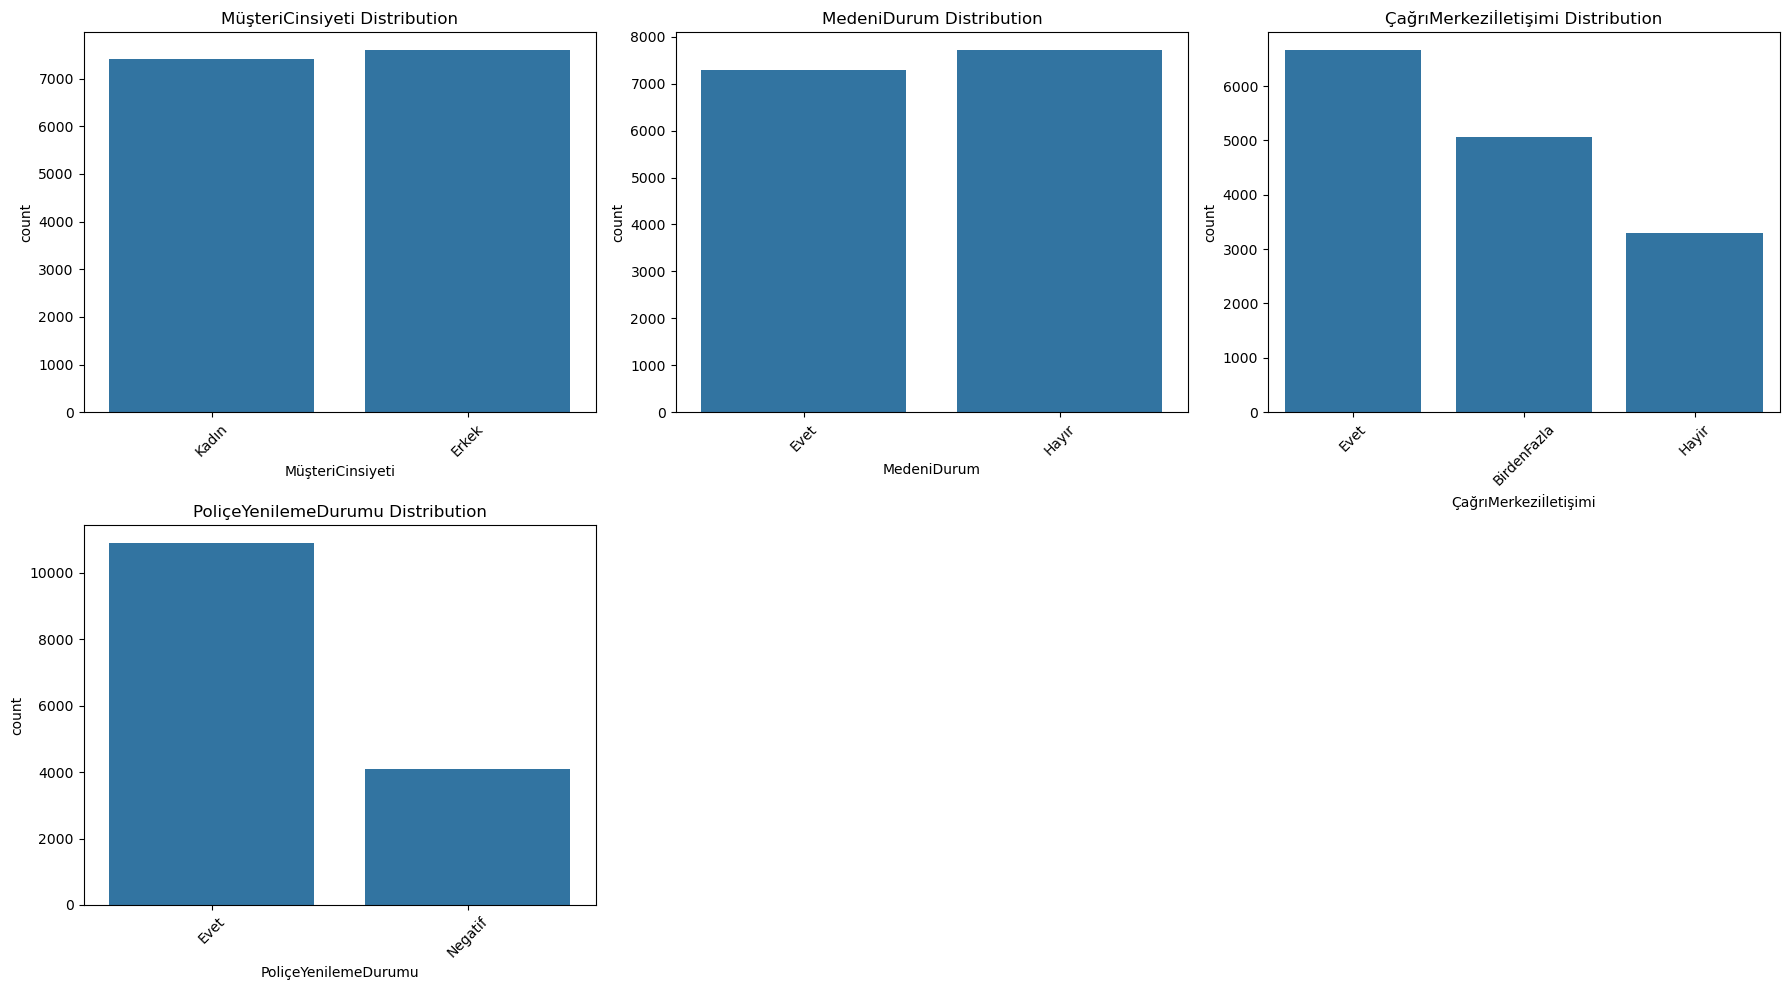

In [28]:
important_cols = ["MüşteriCinsiyeti", "MedeniDurum", "ÇağrıMerkeziİletişimi", "PoliçeYenilemeDurumu"]

n_cols = 3
n_rows = math.ceil(len(important_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))
for i, col in enumerate(important_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.countplot(data=df, x=col)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

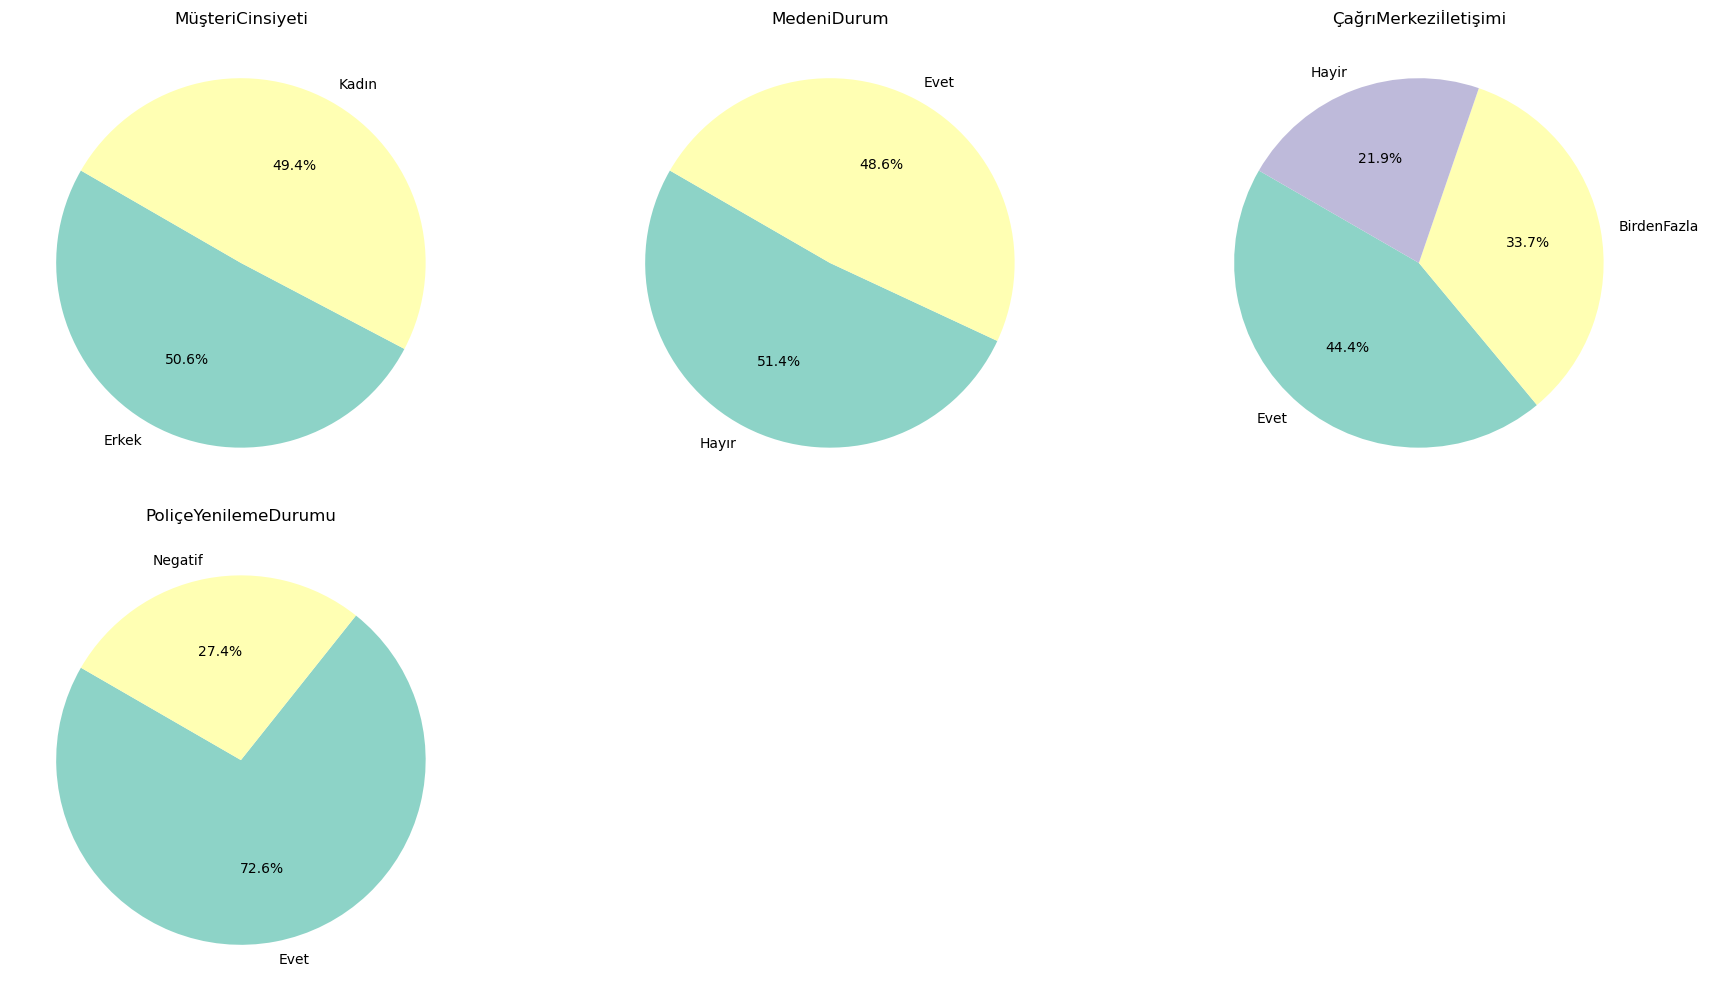

In [29]:
n_cols = 3  # her satırda 3 grafik
n_rows = math.ceil(len(cat_cols) / n_cols)
colors = cm.Set3.colors

plt.figure(figsize=(18, 5 * n_rows))
for i, col in enumerate(important_cols):
    plt.subplot(n_rows, n_cols, i+1)
    value_counts = df[col].value_counts()
    plt.pie(
        value_counts,
        labels=value_counts.index,
        autopct='%1.1f%%',
        startangle=150,
        colors=colors[:len(value_counts)])
    plt.title(f"{col}")
plt.tight_layout()
plt.show()

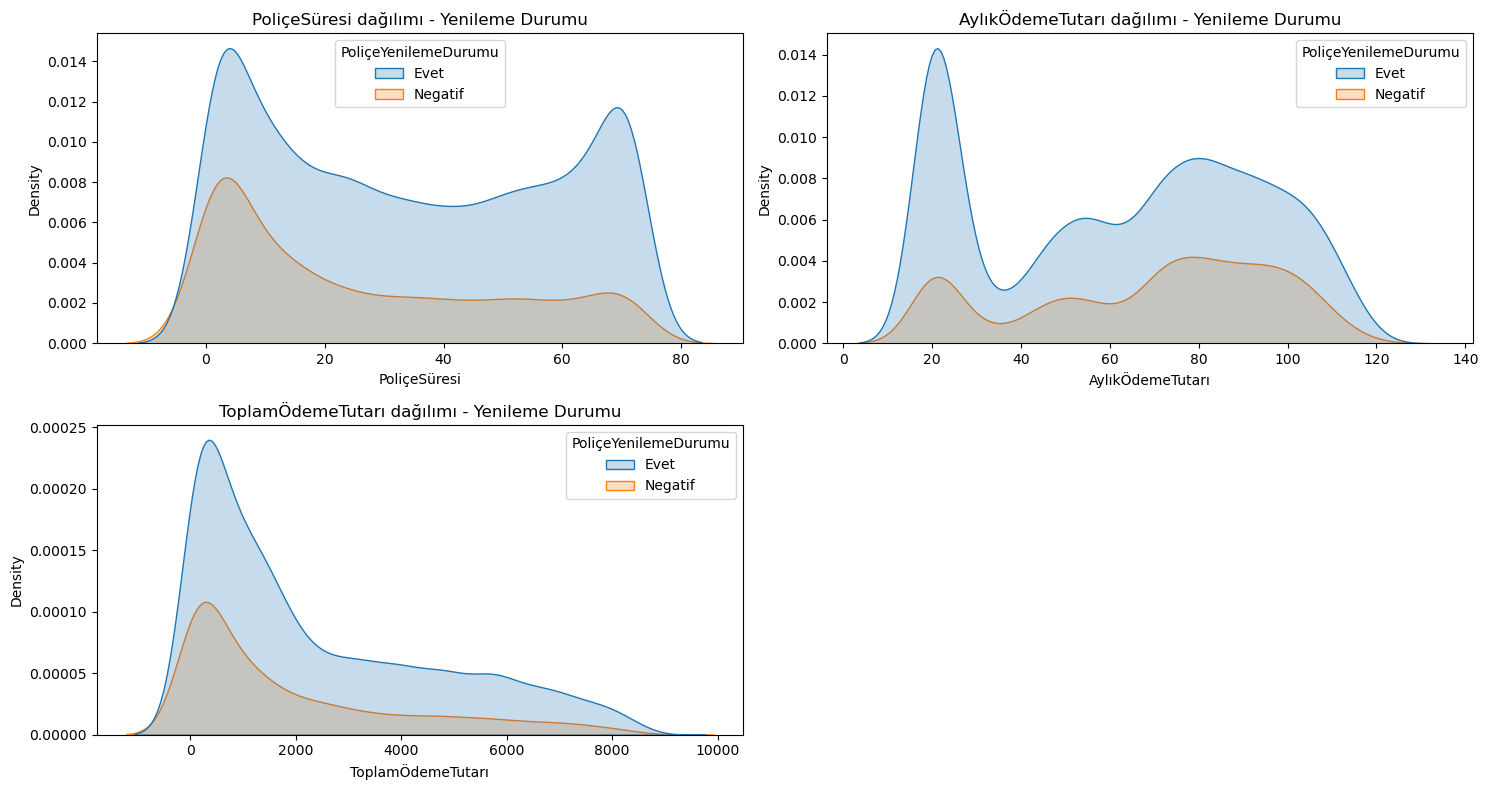

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = ["PoliçeSüresi",
            "AylıkÖdemeTutarı",
            "ToplamÖdemeTutarı"]

plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(data=df, x=col, hue="PoliçeYenilemeDurumu", fill=True)
    plt.title(f"{col} dağılımı - Yenileme Durumu")
    
plt.tight_layout()
plt.show()

## Outlier Detection

In [31]:
def calculate_LB_UB(df, var):
    '''calculating upper bound and lower bound values to identify outliers'''
    Q3 = np.percentile(df[var], 75)
    Q1 = np.percentile(df[var], 25)
    IQR = 1.5 * (Q3 - Q1)

    UB = Q3 + IQR
    LB = Q1 - IQR

    print(LB, UB)

    return LB, UB

In [32]:
calculate_LB_UB(df, "AylıkÖdemeTutarı")
calculate_LB_UB(df, "ToplamÖdemeTutarı")
calculate_LB_UB(df, "PoliçeSüresi")

-47.5 172.5
-4687.0 8905.0
-62.5 125.5


(np.float64(-62.5), np.float64(125.5))

In [33]:
#numerical_columns = df.select_dtypes('float64', 'int').columns

for i in num_cols:
    print("\n name of column:", i)
    LB, UB = calculate_LB_UB(df, i)
    print("min and max value", (df[i].min(), df[i].max()))
    print("range of outliers:", LB, UB)
    
    if df[i].max() > UB or df[i].min() < LB:
        print("----Investigate variable for outliers---")


 name of column: PoliçeSüresi
-62.5 125.5
min and max value (0, 72)
range of outliers: -62.5 125.5

 name of column: AylıkÖdemeTutarı
-47.5 172.5
min and max value (18, 119)
range of outliers: -47.5 172.5

 name of column: ToplamÖdemeTutarı
-4687.0 8905.0
min and max value (19, 8685)
range of outliers: -4687.0 8905.0


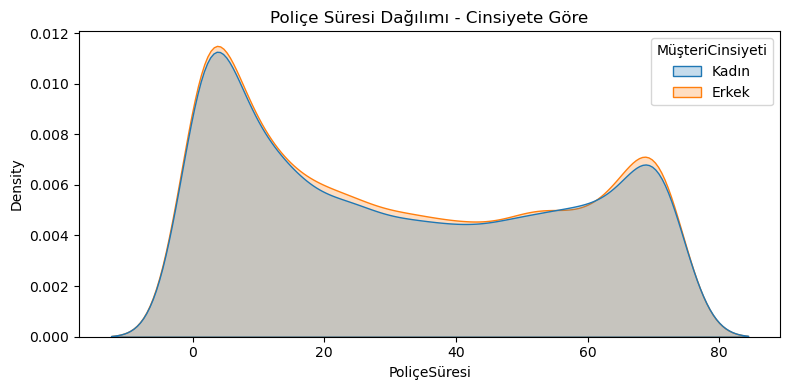

In [34]:
plt.figure(figsize=(8,4))

sns.kdeplot(data=df,
            x="PoliçeSüresi",
            hue="MüşteriCinsiyeti",
            fill=True)

plt.title("Poliçe Süresi Dağılımı - Cinsiyete Göre")
plt.tight_layout()
plt.show()

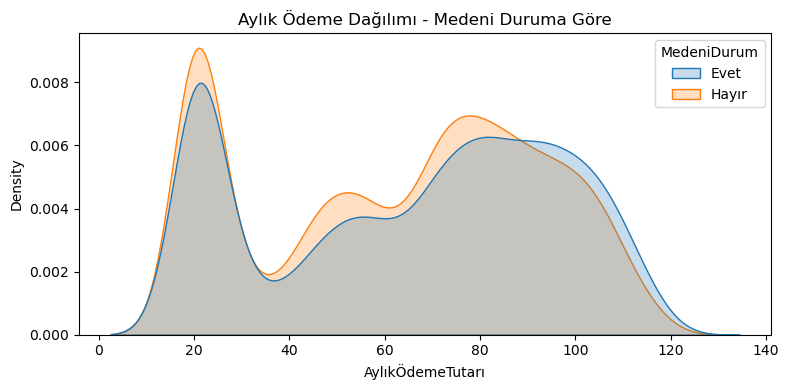

In [35]:
plt.figure(figsize=(8,4))

sns.kdeplot(data=df,
            x="AylıkÖdemeTutarı",
            hue="MedeniDurum",
            fill=True)

plt.title("Aylık Ödeme Dağılımı - Medeni Duruma Göre")
plt.tight_layout()
plt.show()

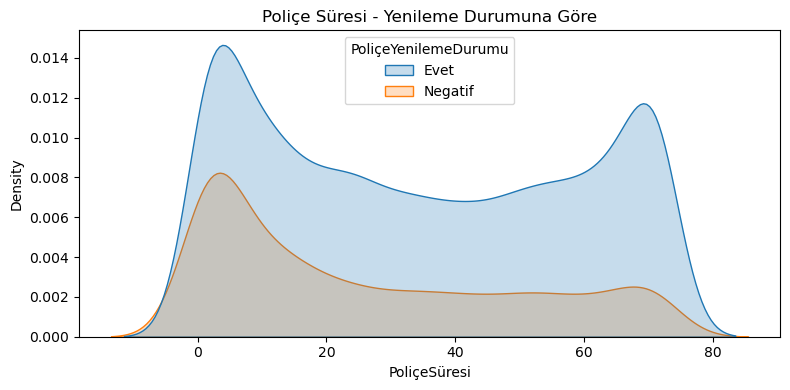

In [36]:
plt.figure(figsize=(8,4))

sns.kdeplot(data=df,
            x="PoliçeSüresi",
            hue="PoliçeYenilemeDurumu",
            fill=True)

plt.title("Poliçe Süresi - Yenileme Durumuna Göre")
plt.tight_layout()
plt.show()


In [37]:
df["MüşteriCinsiyeti"].value_counts()

MüşteriCinsiyeti
Erkek    7594
Kadın    7406
Name: count, dtype: int64

In [38]:
df["PoliçeYenilemeDurumu"].value_counts()

PoliçeYenilemeDurumu
Evet       10895
Negatif     4105
Name: count, dtype: int64

In [39]:
#% olarak kaçı yeniliyor? kaç tanesi kayıp?
df["PoliçeYenilemeDurumu"].value_counts(normalize=True)

PoliçeYenilemeDurumu
Evet       0.726333
Negatif    0.273667
Name: proportion, dtype: float64

In [40]:
#cinsiyet ve yenileme ilişkisi
pd.crosstab(df["MüşteriCinsiyeti"], df["PoliçeYenilemeDurumu"])

PoliçeYenilemeDurumu,Evet,Negatif
MüşteriCinsiyeti,,
Erkek,5507,2087
Kadın,5388,2018


In [41]:
pd.crosstab(df["MüşteriCinsiyeti"], df["PoliçeYenilemeDurumu"], normalize = "index")

PoliçeYenilemeDurumu,Evet,Negatif
MüşteriCinsiyeti,,
Erkek,0.725178,0.274822
Kadın,0.727518,0.272482


In [42]:
#medeni durum ve yenileme ilişkisi
pd.crosstab(df["MedeniDurum"], df["PoliçeYenilemeDurumu"])

PoliçeYenilemeDurumu,Evet,Negatif
MedeniDurum,,
Evet,5543,1748
Hayır,5352,2357


In [43]:
pd.crosstab(df["ÇocukVarmı"], df["PoliçeYenilemeDurumu"])

PoliçeYenilemeDurumu,Evet,Negatif
ÇocukVarmı,,
Evet,3532,982
Hayır,7363,3123


In [44]:
#çağrı merkezi önemli mi
pd.crosstab(df["ÇağrıMerkeziİletişimi"], df["PoliçeYenilemeDurumu"])

PoliçeYenilemeDurumu,Evet,Negatif
ÇağrıMerkeziİletişimi,,
BirdenFazla,3775,1281
Evet,4430,2225
Hayir,2690,599


In [45]:
#ödeme - yenileme ilişkisi
df.groupby("PoliçeYenilemeDurumu").agg({"AylıkÖdemeTutarı" : "mean"})

,AylıkÖdemeTutarı
PoliçeYenilemeDurumu,
Evet,62.733272
Negatif,68.596833


In [46]:
#ürün kırılımları
#“Sağlığı olan müşteriye araç satmak mantıklı mı?
pd.crosstab(df["SağlıkSigortasıVarlığı"], df["AraçSigortasıVarlığı"])

AraçSigortasıVarlığı,Rakip,Sigortasiz,Var
SağlıkSigortasıVarlığı,,,
VarKapsamli,2865,328,3407
VarStandard,2374,942,1820
Yok,2029,177,1058


In [47]:
df.groupby("PoliçeYenilemeDurumu")[num_cols].mean()

,PoliçeSüresi,AylıkÖdemeTutarı,ToplamÖdemeTutarı
PoliçeYenilemeDurumu,,,
Evet,34.357595,62.733272,2416.510785
Negatif,25.780999,68.596833,1954.098660


In [48]:
pd.crosstab(df["ÖdemeYöntemi"], df["PoliçeYenilemeDurumu"], normalize="index")

PoliçeYenilemeDurumu,Evet,Negatif
ÖdemeYöntemi,,
Kredi Kartı ile Taksitli Ödeme,0.769392,0.230608
Otomatik Ödeme Talimatı,0.640447,0.359553


In [49]:
pd.crosstab(df["SağlıkSigortasıVarlığı"], df["AmeliyatGeçmişi"], normalize="index")

AmeliyatGeçmişi,Evet,Hayir,Planlanan
SağlıkSigortasıVarlığı,,,
VarKapsamli,0.464848,0.525000,0.010152
VarStandard,0.392329,0.598326,0.009346
Yok,0.206189,0.742953,0.050858


In [50]:
pd.crosstab(df["SağlıkSigortasıVarlığı"],
            df["AmeliyatGeçmişi"],
            normalize="columns")

AmeliyatGeçmişi,Evet,Hayir,Planlanan
SağlıkSigortasıVarlığı,,,
VarKapsamli,0.533009,0.386589,0.238434
VarStandard,0.350069,0.342854,0.170819
Yok,0.116921,0.270557,0.590747


In [51]:
pd.crosstab(
    [df["SağlıkSigortasıVarlığı"], df["AmeliyatGeçmişi"]],
    df["PoliçeYenilemeDurumu"],
    normalize="index"
)

PoliçeYenilemeDurumu                        Evet   Negatif
SağlıkSigortasıVarlığı AmeliyatGeçmişi                    
VarKapsamli            Evet             0.649935  0.350065
                       Hayir            0.659163  0.340837
                       Planlanan        0.776119  0.223881
VarStandard            Evet             0.788089  0.211911
                       Hayir            0.744224  0.255776
                       Planlanan        0.645833  0.354167
Yok                    Evet             0.725111  0.274889
                       Hayir            0.833814  0.166186
                       Planlanan        0.897590  0.102410

In [52]:
df["PoliçeSüresi"].mean()

np.float64(32.010466666666666)

In [53]:
#Poliçe Süresi Artınca Retention Artıyor mu?

df.groupby("PoliçeSüresi").agg({"YenilemeBinary" : "mean"})

,YenilemeBinary
PoliçeSüresi,
0,0.850000
1,0.556877
2,0.629213
3,0.614458
4,0.653747
...,...
68,0.839779
69,0.806763
70,0.782258


## Feature Extraction

In [54]:
#Trying to get new features from the data with high correlation 
df["OrtalamaAylikOdeme"] = df["ToplamÖdemeTutarı"] / df["PoliçeSüresi"]

In [55]:
df["ToplamÜrünSayısı"] = (
    (df["EvSigortasıVarlığı"] == "Var").astype(int) +
    (df["AraçSigortasıVarlığı"] == "Var").astype(int) +
    (df["SağlıkSigortasıVarlığı"].isin(["VarStandard", "VarKapsamli"])).astype(int) +
    (df["TicariSigortaVarlığı"].isin(["Var", "TicariDegil"])).astype(int) +
    (df["AileHayatSigortasıVarlığı"].isin(["Var", "TekKisi"])).astype(int))

In [56]:
df["UrunBasinaOdeme"] = df["ToplamÖdemeTutarı"] / df["ToplamÜrünSayısı"].replace(0,1)

In [57]:
df["UrunYogunlugu"] = df["ToplamÜrünSayısı"] / df["PoliçeSüresi"].replace(0,1)

In [58]:
df["ErkenDonem"] = (df["PoliçeSüresi"] <= 12).astype(int)

In [59]:
new_cols = ["OrtalamaAylikOdeme",
            "UrunBasinaOdeme",
            "UrunYogunlugu",
            "ErkenDonem"]

df[new_cols + ["YenilemeBinary"]].corr()["YenilemeBinary"]

OrtalamaAylikOdeme   -0.017892
UrunBasinaOdeme       0.076230
UrunYogunlugu        -0.133161
ErkenDonem           -0.141882
YenilemeBinary        1.000000
Name: YenilemeBinary, dtype: float64

In [60]:
df["Süre_x_Urun"] = df["PoliçeSüresi"] * df["ToplamÜrünSayısı"]

In [61]:
df["ErkenDonem"].value_counts()

ErkenDonem
0    10251
1     4749
Name: count, dtype: int64

In [62]:
churn_df = df[df["YenilemeBinary"] == 0]

In [63]:
churn_df[cols].value_counts() #BURAYA BAK!!!!!!

NameError: name 'cols' is not defined

## splitting the data

In [235]:
from sklearn.model_selection import train_test_split

In [236]:
y = df["YenilemeBinary"]

In [237]:
X = df.drop(["PoliçeNumarası",
             "PoliçeYenilemeDurumu",
             "YenilemeBinary"], axis=1)

KeyError: "['PoliçeNumarası'] not found in axis"

In [238]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [239]:
y_train.mean(), y_test.mean()

(np.float64(0.7263333333333334), np.float64(0.7263333333333334))

In [240]:
num_cols = ["PoliçeSüresi",
            "AylıkÖdemeTutarı",
            "ToplamÖdemeTutarı",
            "ToplamÜrünSayısı",
            "ErkenDonem",
            "UrunYogunlugu"]

X = df[num_cols]

##### encoding

In [241]:
X = pd.get_dummies(X, drop_first=True)

In [242]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [243]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [244]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced')

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.45      0.28      0.34       821
           1       0.76      0.88      0.82      2179

    accuracy                           0.71      3000
   macro avg       0.61      0.58      0.58      3000
weighted avg       0.68      0.71      0.69      3000



In [245]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import pandas as pd

models = {
    "Logistic": LogisticRegression(class_weight='balanced', max_iter=1000),
    "RandomForest": RandomForestClassifier(class_weight='balanced'),
    "GradientBoosting": GradientBoostingClassifier(),
    "DecisionTree": DecisionTreeClassifier(class_weight='balanced'),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Recall_Churn": report['0']['recall'],
        "F1_Churn": report['0']['f1-score'],
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="Recall_Churn", ascending=False)

,Model,Recall_Churn,F1_Churn,ROC_AUC
0,Logistic,0.577345,0.448015,0.638425
3,DecisionTree,0.411693,0.409449,0.592601
1,RandomForest,0.278928,0.346970,0.651050
4,KNN,0.246041,0.308397,0.621629
2,GradientBoosting,0.119367,0.200000,0.664189


In [246]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_model = LogisticRegression(class_weight='balanced', max_iter=1000)

rf_model = RandomForestClassifier(class_weight='balanced')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [247]:
roc_scores_log = cross_val_score(
    log_model,
    X,
    y,
    cv=skf,
    scoring="roc_auc"
)

print("Logistic ROC-AUC scores:", roc_scores_log)
print("Logistic Mean ROC-AUC:", roc_scores_log.mean())

Logistic ROC-AUC scores: [0.62995547 0.63669598 0.61506524 0.62333905 0.65756622]
Logistic Mean ROC-AUC: 0.6325243898826077


In [248]:
roc_scores_rf = cross_val_score(
    rf_model,
    X,
    y,
    cv=skf,
    scoring="roc_auc"
)

print("RF ROC-AUC scores:", roc_scores_rf)
print("RF Mean ROC-AUC:", roc_scores_rf.mean())

RF ROC-AUC scores: [0.632896   0.6428054  0.63478789 0.61460352 0.66320078]
RF Mean ROC-AUC: 0.637658716605579


### Standardization

In [249]:
df["UrunBasinaOdeme"] = df["ToplamÖdemeTutarı"] / df["ToplamÜrünSayısı"]

In [250]:
df["UrunYogunlugu"] = df["ToplamÜrünSayısı"] / df["PoliçeSüresi"]

In [251]:
X = df.drop("YenilemeBinary", axis=1)
y = df["YenilemeBinary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [252]:
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)

In [253]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

# numeric kolon listesi
num_cols = ["AylıkÖdemeTutarı",
            "ToplamÖdemeTutarı",
            "PoliçeSüresi",
            "ToplamÜrünSayısı",
            "UrunBasinaOdeme",
            "UrunYogunlugu"]

# sadece train üzerinde fit
X_train_num_scaled = pd.DataFrame(sc.fit_transform(X_train[num_cols]),
                                  columns=num_cols,
                                  index=X_train.index)

# testte sadece transform
X_test_num_scaled = pd.DataFrame(sc.transform(X_test[num_cols]),
                                 columns=num_cols,
                                 index=X_test.index)

In [254]:
X_train_num_scaled.head()

,AylıkÖdemeTutarı,ToplamÖdemeTutarı,PoliçeSüresi,ToplamÜrünSayısı,UrunBasinaOdeme,UrunYogunlugu
10634,1.511592,-0.914794,-1.056935,-0.323013,-0.838224,-0.016326
10256,-1.465437,1.677851,0.082742,-0.323013,1.723041,-0.450092
13594,-1.465437,2.006824,-0.080069,0.720367,1.304527,-0.402584
2987,-1.465437,-0.708966,0.042039,-1.366394,-0.489336,-0.479198
633,-1.465437,-0.926229,-0.894124,-0.323013,-0.849520,-0.227012


In [255]:
X_test_num_scaled.head()

,AylıkÖdemeTutarı,ToplamÖdemeTutarı,PoliçeSüresi,ToplamÜrünSayısı,UrunBasinaOdeme,UrunYogunlugu
14304,0.353858,-0.453880,-0.853421,1.763748,-0.600128,-0.064209
11301,-1.465437,-0.660587,-0.527799,-0.323013,-0.587094,-0.376711
3736,-1.465437,-0.941622,-0.975529,-0.323013,-0.864727,-0.148005
13820,-0.340782,-0.796927,1.141013,-0.323013,-0.721783,-0.490370
13178,-1.432359,1.635630,0.937499,-0.323013,1.681330,-0.485582


In [256]:
###### benim denemelerim

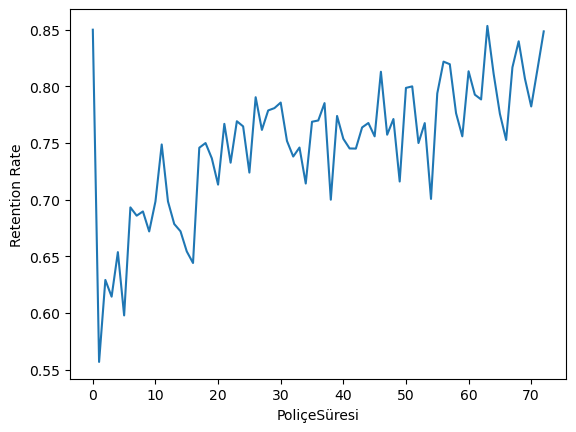

In [257]:
df.groupby("PoliçeSüresi")["YenilemeBinary"].mean().plot()
plt.ylabel("Retention Rate")
plt.show()

In [258]:
df["SureSegment"] = pd.cut(
    df["PoliçeSüresi"],
    bins=[-1,12,24,36,48,120],
    labels=["0-12","12-24","24-36","36-48","48+"])

In [259]:
df.groupby("SureSegment")["YenilemeBinary"].mean()

SureSegment
0-12     0.633397
12-24    0.716972
24-36    0.759015
36-48    0.761250
48+      0.800169
Name: YenilemeBinary, dtype: float64

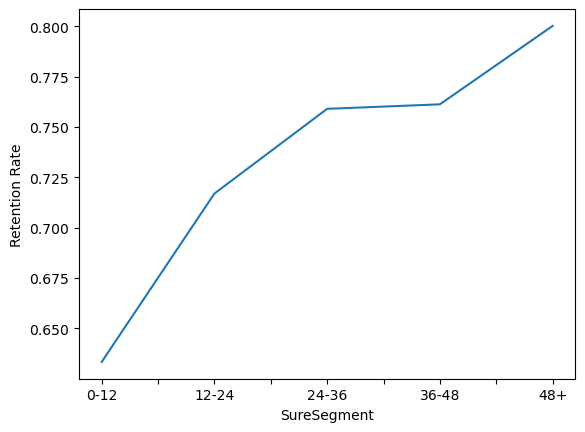

In [260]:
df.groupby("SureSegment")["YenilemeBinary"].mean().plot()
plt.ylabel("Retention Rate")
plt.show()

In [261]:
#Rakipte Olanlar Daha mı Çok Churn Ediyor?

df.groupby("AraçSigortasıVarlığı").agg({"YenilemeBinary" : "mean"})

,YenilemeBinary
AraçSigortasıVarlığı,
Rakip,0.732113
Sigortasiz,0.720111
Var,0.721082


In [262]:
pd.crosstab(
    [df["AraçSigortasıVarlığı"], df["SağlıkSigortasıVarlığı"]],
    df["YenilemeBinary"],
    normalize="index")

YenilemeBinary                                      0         1
AraçSigortasıVarlığı SağlıkSigortasıVarlığı                    
Rakip                VarKapsamli             0.357766  0.642234
                     VarStandard             0.247683  0.752317
                     Yok                     0.164613  0.835387
Sigortasiz           VarKapsamli             0.314024  0.685976
                     VarStandard             0.261146  0.738854
                     Yok                     0.316384  0.683616
Var                  VarKapsamli             0.335192  0.664808
                     VarStandard             0.217582  0.782418
                     Yok                     0.203214  0.796786

In [263]:
pd.crosstab(df["AraçSigortasıVarlığı"], df["PoliçeYenilemeDurumu"], normalize="index")

PoliçeYenilemeDurumu,Evet,Negatif
AraçSigortasıVarlığı,,
Rakip,0.732113,0.267887
Sigortasiz,0.720111,0.279889
Var,0.721082,0.278918


In [264]:
#Yüksek Ödeme Yapanlar mı Daha Çok Ayrılıyor?

df.groupby("PoliçeYenilemeDurumu")["ToplamÖdemeTutarı"].describe()

,count,mean,std,min,25%,50%,75%,max
PoliçeYenilemeDurumu,,,,,,,,
Evet,10895.0,2416.510785,2303.443623,19.0,485.5,1519.0,4016.0,8685.0
Negatif,4105.0,1954.098660,2169.623807,19.0,237.0,1058.0,3028.0,8685.0


In [265]:
df["OdemeSegment"] = pd.qcut(df["ToplamÖdemeTutarı"], 4)

pd.crosstab(df["OdemeSegment"],
            df["PoliçeYenilemeDurumu"],
            normalize="index")

PoliçeYenilemeDurumu,Evet,Negatif
OdemeSegment,,
"(18.999, 410.0]",0.647827,0.352173
"(410.0, 1400.5]",0.729795,0.270205
"(1400.5, 3808.0]",0.745605,0.254395
"(3808.0, 8685.0]",0.782168,0.217832


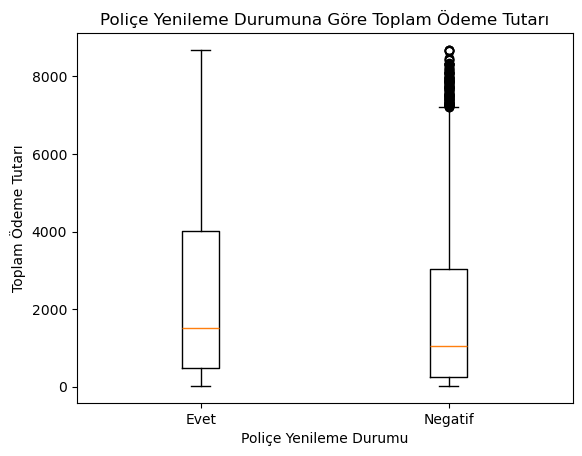

In [266]:
# Poliçe yenileme durumuna göre Toplam Ödeme Tutarı karşılaştırması (Boxplot)

import matplotlib.pyplot as plt

# Veriyi iki gruba ayıralım
yenileyenler = df[df["PoliçeYenilemeDurumu"] == "Evet"]["ToplamÖdemeTutarı"]
yenilemeyenler = df[df["PoliçeYenilemeDurumu"] == "Negatif"]["ToplamÖdemeTutarı"]

# Grafik
plt.figure()
plt.boxplot([yenileyenler, yenilemeyenler], labels=["Evet", "Negatif"])
plt.xlabel("Poliçe Yenileme Durumu")
plt.ylabel("Toplam Ödeme Tutarı")
plt.title("Poliçe Yenileme Durumuna Göre Toplam Ödeme Tutarı")
plt.show()


In [267]:
threshold = df["ToplamÖdemeTutarı"].quantile(0.95)

outliers = df[df["ToplamÖdemeTutarı"] > threshold]

outliers["PoliçeYenilemeDurumu"].value_counts(normalize=True)

PoliçeYenilemeDurumu
Evet       0.781333
Negatif    0.218667
Name: proportion, dtype: float64

In [268]:
threshold = df["ToplamÖdemeTutarı"].quantile(0.05)

low_segment = df[df["ToplamÖdemeTutarı"] <= threshold]

low_segment["PoliçeYenilemeDurumu"].value_counts(normalize=True)

PoliçeYenilemeDurumu
Evet       0.646914
Negatif    0.353086
Name: proportion, dtype: float64

In [269]:
df.groupby("MüşteriCinsiyeti")["YenilemeBinary"].mean()

MüşteriCinsiyeti
Erkek    0.725178
Kadın    0.727518
Name: YenilemeBinary, dtype: float64

In [270]:
#Ürün Sahipliği Analizi

product_cols = ["EvSigortasıVarlığı","AraçSigortasıVarlığı",
                "SağlıkSigortasıVarlığı","TicariSigortaVarlığı", "AileHayatSigortasıVarlığı"]

In [271]:
cols = [
    "EvSigortasıVarlığı",
    "AraçSigortasıVarlığı",
    "SağlıkSigortasıVarlığı",
    "TicariSigortaVarlığı",
    "AileHayatSigortasıVarlığı"
]

for col in cols:
    df[col] = df[col].str.strip().str.lower()

In [272]:
df["ToplamÜrünSayısı"] = (
    (df["EvSigortasıVarlığı"] == "var").astype(int) +
    (df["AraçSigortasıVarlığı"] == "var").astype(int) +
    (df["SağlıkSigortasıVarlığı"].isin(["varstandard", "varkapsamli"])).astype(int) +
    (df["TicariSigortaVarlığı"].isin(["var", "ticaridegil"])).astype(int) +
    (df["AileHayatSigortasıVarlığı"].isin(["var", "tekkisi"])).astype(int))

In [273]:
df[df["ToplamÜrünSayısı"] == 0][[
    "EvSigortasıVarlığı",
    "AraçSigortasıVarlığı",
    "SağlıkSigortasıVarlığı",
    "TicariSigortaVarlığı",
    "AileHayatSigortasıVarlığı"
]].value_counts()

EvSigortasıVarlığı  AraçSigortasıVarlığı  SağlıkSigortasıVarlığı  TicariSigortaVarlığı  AileHayatSigortasıVarlığı
yok                 rakip                 yok                     rakipte               yok                          17
                    sigortasiz            yok                     rakipte               yok                           2
Name: count, dtype: int64

In [274]:
df[df["ToplamÜrünSayısı"] == 0].shape

(19, 29)

In [275]:
yeni = df[df["ToplamÜrünSayısı"]==0]

In [276]:
df_zero = df[df["ToplamÜrünSayısı"] == 0]

df_zero.to_excel("ToplamUrunSayisi_0.xlsx", index=False)

In [277]:
df["EnAzBirUrunVarMi"] = (
    (df["EvSigortasıVarlığı"] == "Var") |
    (df["AraçSigortasıVarlığı"] == "Var") |
    (df["SağlıkSigortasıVarlığı"].isin(["VarStandard", "VarKapsamlı"])) |
    (df["TicariSigortaVarlığı"].isin(["Var", "TicariDeğil"]))
).astype(int)

In [278]:
pd.crosstab(df["EnAzBirUrunVarMi"], df["ToplamÜrünSayısı"] > 0)

ToplamÜrünSayısı,False,True
EnAzBirUrunVarMi,,
0,19,14981


In [279]:
df[(df["EnAzBirUrunVarMi"] == 1) & (df["ToplamÜrünSayısı"] == 0)]

,MüşteriCinsiyeti,_65YaşÜzeri,MedeniDurum,ÇocukVarmı,PoliçeSüresi,EvSigortasıVarlığı,AraçSigortasıVarlığı,SağlıkSigortasıVarlığı,TicariSigortaVarlığı,MobilUygulamaKullanımı,...,YenilemeBinary,OrtalamaAylikOdeme,ToplamÜrünSayısı,UrunBasinaOdeme,UrunYogunlugu,ErkenDonem,Süre_x_Urun,SureSegment,OdemeSegment,EnAzBirUrunVarMi


In [280]:
df[(df["ToplamÜrünSayısı"] == 0) & (df["EnAzBirUrunVarMi"] == 1)]

,MüşteriCinsiyeti,_65YaşÜzeri,MedeniDurum,ÇocukVarmı,PoliçeSüresi,EvSigortasıVarlığı,AraçSigortasıVarlığı,SağlıkSigortasıVarlığı,TicariSigortaVarlığı,MobilUygulamaKullanımı,...,YenilemeBinary,OrtalamaAylikOdeme,ToplamÜrünSayısı,UrunBasinaOdeme,UrunYogunlugu,ErkenDonem,Süre_x_Urun,SureSegment,OdemeSegment,EnAzBirUrunVarMi


In [281]:
df[df["ToplamÜrünSayısı"] == 0]["PoliçeYenilemeDurumu"].value_counts(normalize=True)

PoliçeYenilemeDurumu
Evet       0.736842
Negatif    0.263158
Name: proportion, dtype: float64

In [282]:
df[df["ToplamÜrünSayısı"] == 0][
    ["PoliçeYenilemeDurumu", "ToplamÖdemeTutarı", "PoliçeNumarası"]
]

KeyError: "['PoliçeNumarası'] not in index"

In [283]:
df.groupby("ToplamÜrünSayısı")["YenilemeBinary"].mean()

ToplamÜrünSayısı
0    0.736842
1    0.707831
2    0.755556
3    0.723719
4    0.693253
5    0.790434
Name: YenilemeBinary, dtype: float64

In [284]:
df["ToplamÜrünSayısı"].describe()

count    15000.000000
mean         3.306933
std          0.962629
min          0.000000
25%          3.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: ToplamÜrünSayısı, dtype: float64

In [285]:
df[df["ToplamÜrünSayısı"] == 0][["PoliçeNumarası", "SözleşmeTürü", "ToplamÖdemeTutarı", "PoliçeYenilemeDurumu"]]

KeyError: "['PoliçeNumarası'] not in index"

In [286]:
df.groupby("ToplamÜrünSayısı")["YenilemeBinary"].mean()

ToplamÜrünSayısı
0    0.736842
1    0.707831
2    0.755556
3    0.723719
4    0.693253
5    0.790434
Name: YenilemeBinary, dtype: float64

In [287]:
df.groupby("SözleşmeTürü")["YenilemeBinary"].mean()

SözleşmeTürü
Prim Geri Ödemeli Hayat Sigortası    0.834938
Temel Hayat Sigortası                0.653450
Özel Hayat Sigortası                 0.792495
Name: YenilemeBinary, dtype: float64

In [288]:
df.groupby("ÖdemeYöntemi")["YenilemeBinary"].mean()

ÖdemeYöntemi
Kredi Kartı ile Taksitli Ödeme    0.769392
Otomatik Ödeme Talimatı           0.640447
Name: YenilemeBinary, dtype: float64

In [289]:
df.groupby("MobilUygulamaKullanımı")["YenilemeBinary"].mean()

MobilUygulamaKullanımı
Kullaniyor     0.747348
Kullanmiyor    0.715232
Name: YenilemeBinary, dtype: float64

In [290]:
df.groupby("ÇağrıMerkeziİletişimi")["YenilemeBinary"].mean()

ÇağrıMerkeziİletişimi
BirdenFazla    0.746638
Evet           0.665665
Hayir          0.817878
Name: YenilemeBinary, dtype: float64

In [291]:
df_zero = df[df["ToplamÜrünSayısı"] == 0]

df_zero[[
    "EvSigortasıVarlığı",
    "AraçSigortasıVarlığı",
    "SağlıkSigortasıVarlığı",
    "TicariSigortaVarlığı",
    "AileHayatSigortasıVarlığı"
]].drop_duplicates()


,EvSigortasıVarlığı,AraçSigortasıVarlığı,SağlıkSigortasıVarlığı,TicariSigortaVarlığı,AileHayatSigortasıVarlığı
7307,yok,rakip,yok,rakipte,yok
10164,yok,sigortasiz,yok,rakipte,yok


In [292]:
df.groupby("ToplamÜrünSayısı")["YenilemeBinary"].mean()

ToplamÜrünSayısı
0    0.736842
1    0.707831
2    0.755556
3    0.723719
4    0.693253
5    0.790434
Name: YenilemeBinary, dtype: float64

In [293]:
df["ToplamÜrünSayısı"].value_counts()

ToplamÜrünSayısı
3    5603
4    4802
2    2655
5    1589
1     332
0      19
Name: count, dtype: int64

In [294]:
df.groupby("ToplamÜrünSayısı").agg({"YenilemeBinary" : "mean"})

,YenilemeBinary
ToplamÜrünSayısı,
0,0.736842
1,0.707831
2,0.755556
3,0.723719
4,0.693253
5,0.790434


In [295]:
df.groupby("ToplamÜrünSayısı").agg({"AylıkÖdemeTutarı" : "mean"})

,AylıkÖdemeTutarı
ToplamÜrünSayısı,
0,78.631579
1,53.864458
2,50.152542
3,60.061931
4,72.951062
5,79.105727


In [296]:
df.groupby("ToplamÜrünSayısı")["PoliçeSüresi"].mean()

ToplamÜrünSayısı
0    33.684211
1    28.888554
2    29.162335
3    29.230591
4    33.680758
5    42.156073
Name: PoliçeSüresi, dtype: float64

In [297]:
summary_table = df.groupby("ToplamÜrünSayısı").agg(
    MusteriSayisi=("YenilemeBinary", "count"),
    RetentionOrani=("YenilemeBinary", "mean"),
    OrtalamaAylikOdeme=("AylıkÖdemeTutarı", "mean"),
    OrtalamaPoliceSuresi=("PoliçeSüresi", "mean")
).reset_index()

In [298]:
summary_table["RetentionOrani"] = summary_table["RetentionOrani"] * 100

In [299]:
summary_table

,ToplamÜrünSayısı,MusteriSayisi,RetentionOrani,OrtalamaAylikOdeme,OrtalamaPoliceSuresi
0,0,19,73.684211,78.631579,33.684211
1,1,332,70.783133,53.864458,28.888554
2,2,2655,75.555556,50.152542,29.162335
3,3,5603,72.371944,60.061931,29.230591
4,4,4802,69.325281,72.951062,33.680758
5,5,1589,79.043424,79.105727,42.156073


In [300]:
## segment bazlı

In [301]:
df["UrunSegment"] = pd.cut(
    df["ToplamÜrünSayısı"],
    bins=[-1,0,1,3,5],
    labels=["0","1","2-3","4-5"]
)

In [302]:
segment_table = df.groupby("UrunSegment").agg(
    MusteriSayisi=("YenilemeBinary", "count"),
    RetentionOrani=("YenilemeBinary", "mean"),
    OrtalamaAylikOdeme=("AylıkÖdemeTutarı", "mean"),
    OrtalamaPoliceSuresi=("PoliçeSüresi", "mean")
).reset_index()

segment_table.round(2)


,UrunSegment,MusteriSayisi,RetentionOrani,OrtalamaAylikOdeme,OrtalamaPoliceSuresi
0,0,19,0.74,78.63,33.68
1,1,332,0.71,53.86,28.89
2,2-3,8258,0.73,56.88,29.21
3,4-5,6391,0.72,74.48,35.79


In [303]:
churn_df = df[df["YenilemeBinary"] == 0]
retention_df = df[df["YenilemeBinary"] == 1]

In [304]:
churn_df["ToplamÖdemeTutarı"].sum()

np.int64(8021575)

In [305]:
df["ToplamÖdemeTutarı"].sum()

np.int64(34349460)

In [306]:
churn_df["ToplamÖdemeTutarı"].sum() / df["ToplamÖdemeTutarı"].sum()

np.float64(0.23352841645836644)

In [307]:
churn_summary = churn_df.agg({
    "AylıkÖdemeTutarı": "mean",
    "ToplamÖdemeTutarı": "mean",
    "PoliçeSüresi": "mean",
    "ToplamÜrünSayısı": "mean"
})

retention_summary = retention_df.agg({
    "AylıkÖdemeTutarı": "mean",
    "ToplamÖdemeTutarı": "mean",
    "PoliçeSüresi": "mean",
    "ToplamÜrünSayısı": "mean"
})


In [308]:
comparison = pd.DataFrame({
    "Churn": churn_summary,
    "Retention": retention_summary
})

comparison

,Churn,Retention
AylıkÖdemeTutarı,68.596833,62.733272
ToplamÖdemeTutarı,1954.098660,2416.510785
PoliçeSüresi,25.780999,34.357595
ToplamÜrünSayısı,3.312058,3.305002


In [309]:
churn_df.groupby("ToplamÜrünSayısı")["YenilemeBinary"].count()

ToplamÜrünSayısı
0       5
1      97
2     649
3    1548
4    1473
5     333
Name: YenilemeBinary, dtype: int64

In [310]:
churn_df.groupby("ToplamÜrünSayısı")["ToplamÖdemeTutarı"].sum()

ToplamÜrünSayısı
0       4370
1     159834
2    1009112
3    2499306
4    3434619
5     914334
Name: ToplamÖdemeTutarı, dtype: int64

In [311]:
#churn toplam gelirin yüzde kaçı
churn_df["ToplamÖdemeTutarı"].sum() / df["ToplamÖdemeTutarı"].sum()

np.float64(0.23352841645836644)

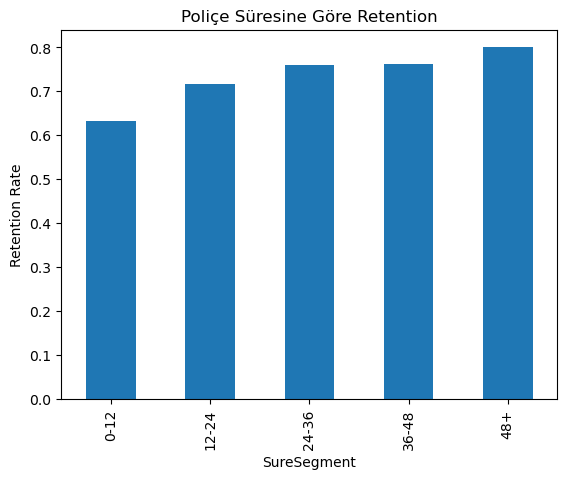

In [312]:
df.groupby("SureSegment")["YenilemeBinary"].mean().plot(kind="bar")
plt.ylabel("Retention Rate")
plt.title("Poliçe Süresine Göre Retention")
plt.show()

In [313]:
corr = df[num_cols].corr()
corr

,AylıkÖdemeTutarı,ToplamÖdemeTutarı,PoliçeSüresi,ToplamÜrünSayısı,UrunBasinaOdeme,UrunYogunlugu
AylıkÖdemeTutarı,1.000000,0.313118,0.110150,0.303006,0.197000,-0.031438
ToplamÖdemeTutarı,0.313118,1.000000,0.388328,0.259642,0.857235,-0.183309
PoliçeSüresi,0.110150,0.388328,1.000000,0.140633,0.299842,-0.566601
ToplamÜrünSayısı,0.303006,0.259642,0.140633,1.000000,-0.099746,0.074937
UrunBasinaOdeme,0.197000,0.857235,0.299842,-0.099746,1.000000,-0.189168
UrunYogunlugu,-0.031438,-0.183309,-0.566601,0.074937,-0.189168,1.000000


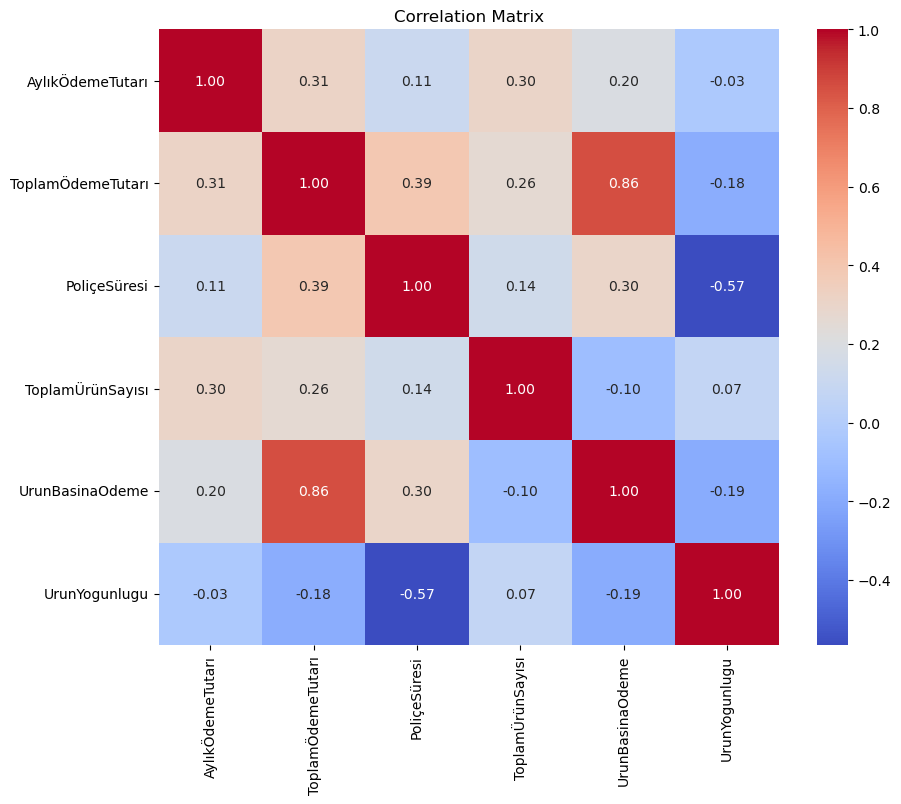

In [314]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [315]:
corr_target = corr["YenilemeBinary"].sort_values(ascending=False)
corr_target

KeyError: 'YenilemeBinary'

In [316]:
cat_cols = ["MüşteriCinsiyeti","_65YaşÜzeri","MedeniDurum",
            "ÇocukVarmı","SözleşmeTürü","BildirimTercihleri",
            "ÖdemeYöntemi","MobilUygulamaKullanımı",
            "ÇağrıMerkeziİletişimi","SonTedaviDetayı"]

for col in cat_cols:
    print("\n", col)
    print(pd.crosstab(df[col], df["PoliçeYenilemeDurumu"], normalize="index"))


 MüşteriCinsiyeti
PoliçeYenilemeDurumu      Evet   Negatif
MüşteriCinsiyeti                        
Erkek                 0.725178  0.274822
Kadın                 0.727518  0.272482

 _65YaşÜzeri
PoliçeYenilemeDurumu      Evet   Negatif
_65YaşÜzeri                             
0                     0.740967  0.259033
1                     0.649771  0.350229

 MedeniDurum
PoliçeYenilemeDurumu      Evet   Negatif
MedeniDurum                             
Evet                  0.760252  0.239748
Hayır                 0.694253  0.305747

 ÇocukVarmı
PoliçeYenilemeDurumu      Evet   Negatif
ÇocukVarmı                              
Evet                  0.782455  0.217545
Hayır                 0.702174  0.297826

 SözleşmeTürü
PoliçeYenilemeDurumu                   Evet   Negatif
SözleşmeTürü                                         
Prim Geri Ödemeli Hayat Sigortası  0.834938  0.165062
Temel Hayat Sigortası              0.653450  0.346550
Özel Hayat Sigortası               0.792495  0.207505

In [317]:
for col in product_cols:
    print(col)
    print(df[col].unique())
    print("------")

EvSigortasıVarlığı
['yok' 'var']
------
AraçSigortasıVarlığı
['sigortasiz' 'rakip' 'var']
------
SağlıkSigortasıVarlığı
['varstandard' 'varkapsamli' 'yok']
------
TicariSigortaVarlığı
['rakipte' 'var' 'ticaridegil']
------
AileHayatSigortasıVarlığı
['yok' 'tekkisi' 'var']
------


In [318]:
df[df["ToplamÜrünSayısı"] == 0][product_cols].drop_duplicates()

,EvSigortasıVarlığı,AraçSigortasıVarlığı,SağlıkSigortasıVarlığı,TicariSigortaVarlığı,AileHayatSigortasıVarlığı
7307,yok,rakip,yok,rakipte,yok
10164,yok,sigortasiz,yok,rakipte,yok


In [319]:
df[df["ToplamÜrünSayısı"] == 0][product_cols].value_counts()

EvSigortasıVarlığı  AraçSigortasıVarlığı  SağlıkSigortasıVarlığı  TicariSigortaVarlığı  AileHayatSigortasıVarlığı
yok                 rakip                 yok                     rakipte               yok                          17
                    sigortasiz            yok                     rakipte               yok                           2
Name: count, dtype: int64

In [320]:
df.groupby("ToplamÜrünSayısı").agg({"AylıkÖdemeTutarı" : "mean"})

,AylıkÖdemeTutarı
ToplamÜrünSayısı,
0,78.631579
1,53.864458
2,50.152542
3,60.061931
4,72.951062
5,79.105727


In [321]:
df[df["ToplamÜrünSayısı"] == 0][["ToplamÖdemeTutarı"]].describe().T

,count,mean,std,min,25%,50%,75%,max
ToplamÖdemeTutarı,19.0,1807.684211,2187.197549,19.0,463.5,980.0,2173.0,7396.0


In [322]:
# 0 ürünlü olup yenileme yapanların verisine bir göz atalım
sifir_urun_hatasi = df[(df["ToplamÜrünSayısı"] == 0) & (df["YenilemeBinary"] == 1)]
print(sifir_urun_hatasi[product_cols].head(10))

      EvSigortasıVarlığı AraçSigortasıVarlığı SağlıkSigortasıVarlığı  \
8005                 yok                rakip                    yok   
8910                 yok                rakip                    yok   
9103                 yok                rakip                    yok   
10164                yok           sigortasiz                    yok   
11043                yok                rakip                    yok   
11149                yok                rakip                    yok   
11181                yok                rakip                    yok   
13332                yok                rakip                    yok   
14043                yok                rakip                    yok   
14209                yok                rakip                    yok   

      TicariSigortaVarlığı AileHayatSigortasıVarlığı  
8005               rakipte                       yok  
8910               rakipte                       yok  
9103               rakipte                

In [323]:
df["YenilediMi"] = df["PoliçeYenilemeDurumu"].map({
    "Evet": 1,
    "Negatif": 0
})

In [65]:
# Risk skorunu 0'dan başlat
df["RiskSkoru"] = 0

#Mobil kullanmayan
df.loc[df["MobilUygulamaKullanımı"] == "Hayır", "RiskSkoru"] += 1

#Tek ürünü olan
df.loc[df["ToplamÜrünSayısı"] == 1, "RiskSkoru"] += 1

#Kısa poliçe süresi (örnek: 12 aydan az)
df.loc[df["PoliçeSüresi"] < 25, "RiskSkoru"] += 1

In [66]:
def risk_seviyesi(x):
    if x <= 1:
        return "Düşük Risk"
    elif x == 2:
        return "Orta Risk"
    else:
        return "Yüksek Risk"

df["RiskSegmenti"] = df["RiskSkoru"].apply(risk_seviyesi)

In [68]:
df

,MüşteriCinsiyeti,_65YaşÜzeri,MedeniDurum,ÇocukVarmı,PoliçeSüresi,EvSigortasıVarlığı,AraçSigortasıVarlığı,SağlıkSigortasıVarlığı,TicariSigortaVarlığı,MobilUygulamaKullanımı,...,PoliçeYenilemeDurumu,YenilemeBinary,OrtalamaAylikOdeme,ToplamÜrünSayısı,UrunBasinaOdeme,UrunYogunlugu,ErkenDonem,Süre_x_Urun,RiskSkoru,RiskSegmenti
0,Kadın,0,Evet,Hayır,1,Yok,Sigortasiz,VarStandard,Rakipte,Kullaniyor,...,Evet,1,30.000000,1,30.000000,1.000000,1,1,2,Orta Risk
1,Erkek,0,Hayır,Hayır,34,Var,Rakip,VarStandard,Var,Kullanmiyor,...,Negatif,0,55.588235,4,472.500000,0.117647,0,136,0,Düşük Risk
2,Erkek,0,Hayır,Hayır,2,Var,Rakip,VarStandard,Var,Kullaniyor,...,Negatif,0,54.000000,4,27.000000,2.000000,1,8,1,Düşük Risk
3,Erkek,0,Hayır,Hayır,45,Yok,Sigortasiz,VarStandard,Var,Kullanmiyor,...,Negatif,0,40.911111,3,613.666667,0.066667,0,135,0,Düşük Risk
4,Kadın,0,Hayır,Hayır,2,Var,Rakip,VarKapsamli,Rakipte,Kullanmiyor,...,Evet,1,76.000000,3,50.666667,1.500000,1,6,1,Düşük Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,Erkek,0,Evet,Hayır,60,Var,Var,Yok,Rakipte,Kullanmiyor,...,Evet,1,66.400000,2,1992.000000,0.033333,0,120,0,Düşük Risk
14996,Erkek,0,Hayır,Evet,32,Var,Rakip,VarKapsamli,Var,Kullanmiyor,...,Evet,1,248.937500,4,1991.500000,0.125000,0,128,0,Düşük Risk
14997,Erkek,0,Hayır,Hayır,51,Var,Var,VarKapsamli,Rakipte,Kullanmiyor,...,Negatif,0,23.980392,4,305.750000,0.078431,0,204,0,Düşük Risk
14998,Erkek,0,Hayır,Hayır,50,Var,Rakip,VarStandard,Rakipte,Kullanmiyor,...,Evet,1,27.640000,3,460.666667,0.060000,0,150,0,Düşük Risk


In [69]:
pd.crosstab(df["RiskSegmenti"], df["YenilemeBinary"], normalize="index")

YenilemeBinary,0,1
RiskSegmenti,,
Düşük Risk,0.272997,0.727003
Orta Risk,0.331395,0.668605


In [73]:
df["RiskSegmenti"].unique()

array(['Orta Risk', 'Düşük Risk'], dtype=object)

In [332]:
features = [
    "_65YaşÜzeri",
    "PoliçeSüresi",
    "AylıkÖdemeTutarı",
    "ToplamÖdemeTutarı",
    "ToplamÜrünSayısı"
]

X = df[features]
y = df["YenilediMi"]


In [333]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X, y)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [334]:
df["ChurnOlasiligi"] = model.predict_proba(X)[:,1]


In [335]:
df["RiskSegmenti_Model"] = pd.cut(
    df["ChurnOlasiligi"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Düşük", "Orta", "Yüksek"]
)


In [336]:
df.head()


,MüşteriCinsiyeti,_65YaşÜzeri,MedeniDurum,ÇocukVarmı,PoliçeSüresi,EvSigortasıVarlığı,AraçSigortasıVarlığı,SağlıkSigortasıVarlığı,TicariSigortaVarlığı,MobilUygulamaKullanımı,...,Süre_x_Urun,SureSegment,OdemeSegment,EnAzBirUrunVarMi,UrunSegment,YenilediMi,RiskSkoru,RiskSegmenti,ChurnOlasiligi,RiskSegmenti_Model
0,Kadın,0,Evet,Hayır,1,yok,sigortasiz,varstandard,rakipte,Kullaniyor,...,1,0-12,"(18.999, 410.0]",0,1,1,2,Orta Risk,0.695246,Yüksek
1,Erkek,0,Hayır,Hayır,34,var,rakip,varstandard,var,Kullanmiyor,...,136,24-36,"(1400.5, 3808.0]",0,4-5,0,0,Düşük Risk,0.759407,Yüksek
2,Erkek,0,Hayır,Hayır,2,var,rakip,varstandard,var,Kullaniyor,...,8,0-12,"(18.999, 410.0]",0,4-5,0,1,Düşük Risk,0.646088,Yüksek
3,Erkek,0,Hayır,Hayır,45,yok,sigortasiz,varstandard,var,Kullanmiyor,...,135,36-48,"(1400.5, 3808.0]",0,2-3,0,0,Düşük Risk,0.808539,Yüksek
4,Kadın,0,Hayır,Hayır,2,var,rakip,varkapsamli,rakipte,Kullanmiyor,...,6,0-12,"(18.999, 410.0]",0,2-3,1,1,Düşük Risk,0.612716,Yüksek


In [337]:
df.to_excel('risksegmentlidosya.xlsx')